In [216]:
import glob
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import skew,ks_2samp
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PowerTransformer, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import ElasticNet, ElasticNetCV,Lasso, LassoCV, BayesianRidge, LassoLarsIC
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb

In [224]:
# Create a dataset containing only important features
directory = r"C:\Users\victo\BGU project\Github\drug_discovery_project\Dataset"

csv_files = glob.glob(directory +'/*.csv')
selected_features = ['MinPartialCharge', 'MaxAbsPartialCharge', 'BCUT2D_LOGPLOW',
       'BCUT2D_MRLOW', 'SMR_VSA10', 'SlogP_VSA1', 'TPSA', 'VSA_EState1',
       'VSA_EState9', 'NHOHCount', 'fr_quatN', 'Binder','RNA_28']
df_reduced = pd.concat((pd.read_csv(f, usecols=selected_features) for f in csv_files), ignore_index=True)

# Limit floats output to 3 decimal points
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

# Removing all zero and positive values of the targe variable
df_reduced = df_reduced[df_reduced['RNA_28'] < 0]
print(df_reduced.head())
print(df_reduced.shape)
print(df_reduced.describe().T)

   MinPartialCharge  MaxAbsPartialCharge  BCUT2D_LOGPLOW  BCUT2D_MRLOW  \
0            -0.370                0.370          -2.154         0.072   
1            -0.341                0.341          -2.827        -0.666   
2            -0.371                0.371          -2.146         0.054   
3            -0.490                0.490          -2.180         0.225   
4            -0.371                0.371          -2.146         0.054   

   SMR_VSA10  SlogP_VSA1   TPSA  VSA_EState1  VSA_EState9  NHOHCount  \
0     43.197       0.000 22.120        5.726        0.000          0   
1     27.267       5.317 29.500        0.000        0.000          2   
2     43.197       0.000 22.120        5.834        0.000          0   
3     59.127       4.737 22.120        5.920        0.000          0   
4     43.197       0.000 22.120        5.834        0.000          0   

   fr_quatN  RNA_28  Binder  
0         0  -5.820       0  
1         1  -7.910       0  
2         0  -5.810       0  
3 

In [225]:
def plot_feature_distribution(df, feature, subset_df=None, subset_feature=None):
    # Ensure feature is numeric for KDE
    if df[feature].dtype not in ['float64', 'int64']:
        print(f"Skipping non-numeric feature: {feature}")
        return
    
    plt.figure(figsize=(8, 5))
    # Plot the distribution of the original data
    original_data = df[feature]
    sns.kdeplot(original_data, label='Original', color='blue')
    original_skew = skew(original_data)  # Skewness of the original data

    # If a subset is provided, plot its distribution as well
    if subset_df is not None and subset_feature is not None:
        subset_data = subset_df[subset_feature]
        sns.kdeplot(subset_data, label='Subset', color='red')
        subset_skew = skew(subset_data)  # Skewness of the subset data

        # Perform KS test to compare the distributions
        ks_stat, p_value = ks_2samp(original_data, subset_data)
        
        print(f"Skewness → Original: {original_skew:.2f}, Subset: {subset_skew:.2f}")
        print(f"KS Test → Statistic: {ks_stat:.4f}, p-value: {p_value:.4f}")
        if ks_stat <= 0.1 and p_value >= 0.05:
           print('The distributions are similar')
        else:
           print('The distributions are not similar')
    else:
        print(f"Skewness → Original: {original_skew:.2f}")
        
    plt.title(f'Distribution of {feature}')
    plt.legend()
    plt.tight_layout()
    plt.show()

Skewness → Original: -1.37


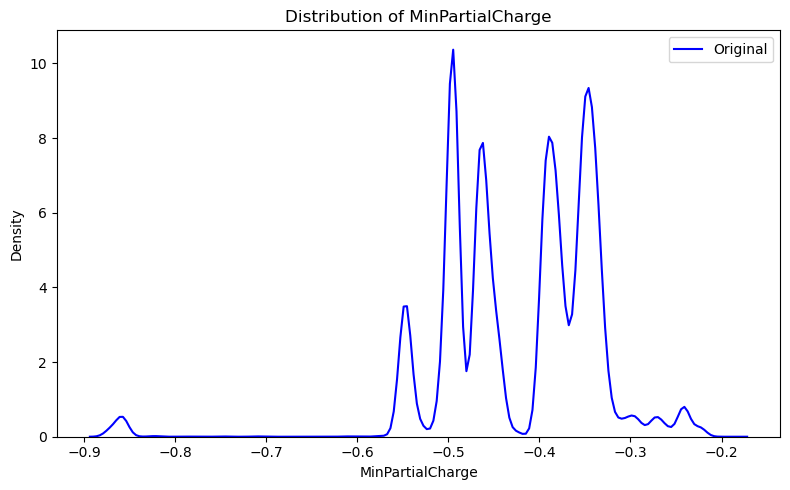

Skewness → Original: 1.45


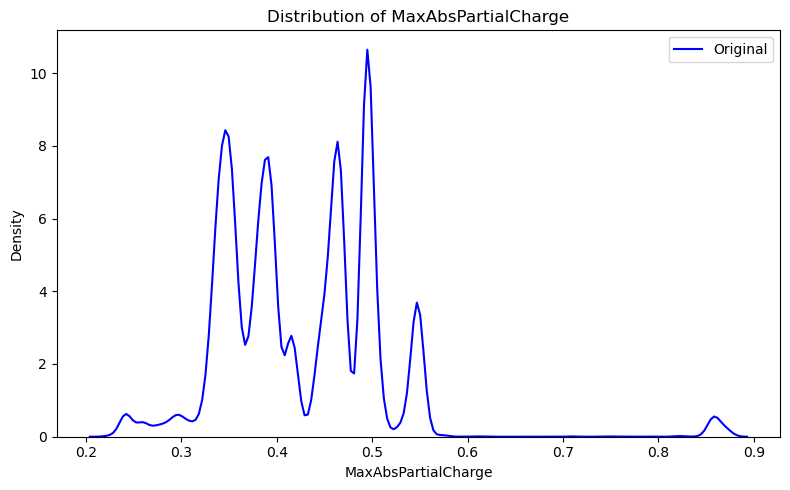

Skewness → Original: -0.89


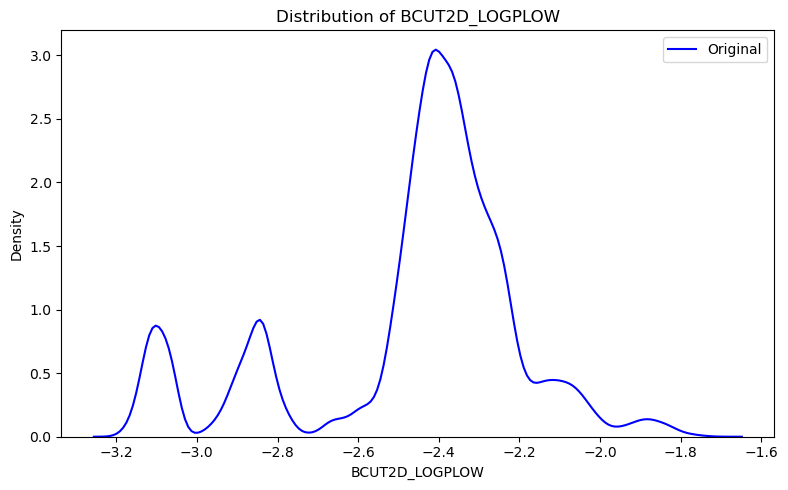

Skewness → Original: -0.34


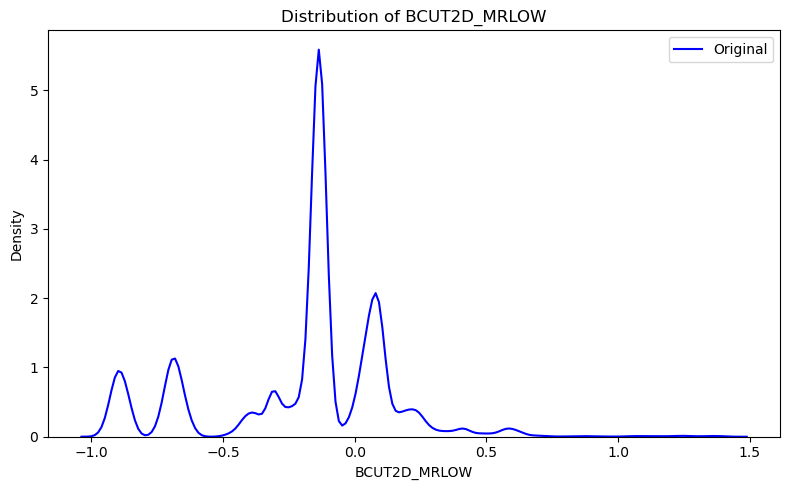

Skewness → Original: 0.75


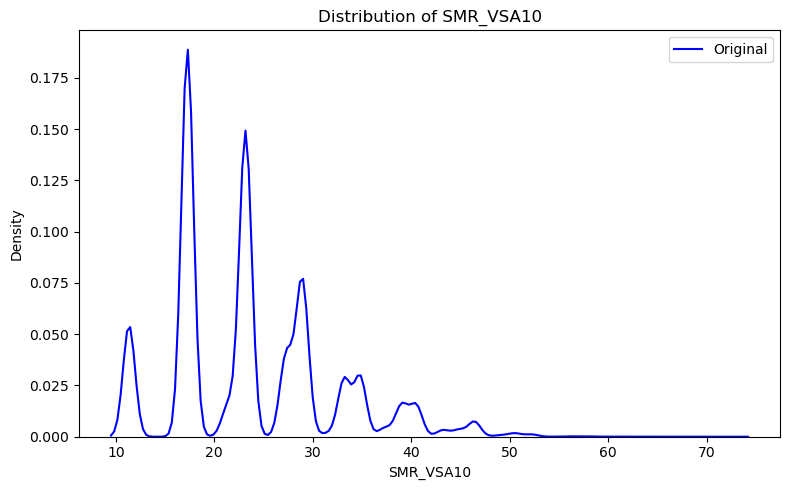

Skewness → Original: 0.39


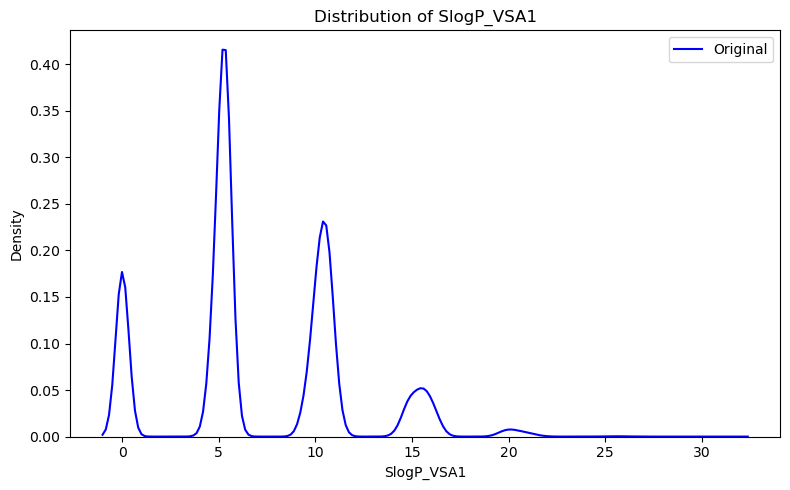

Skewness → Original: 0.27


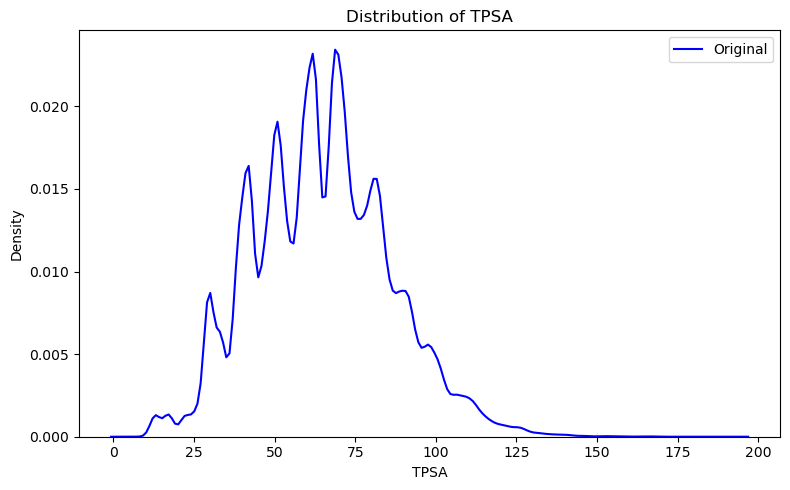

Skewness → Original: 1.30


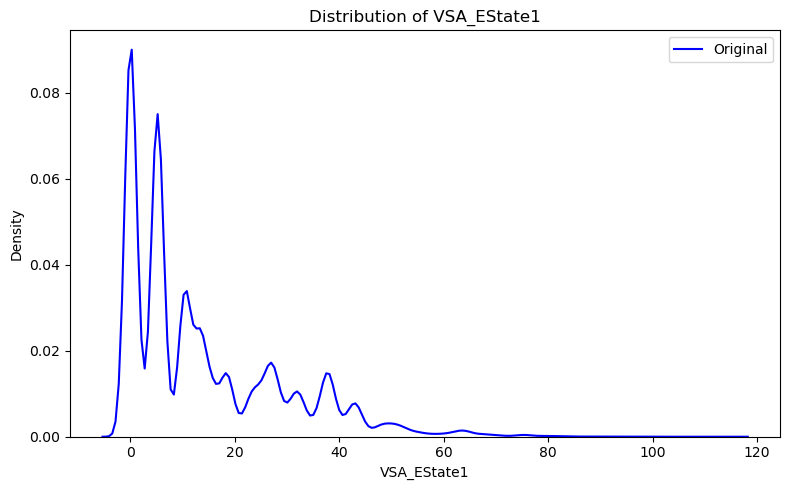

Skewness → Original: -0.01


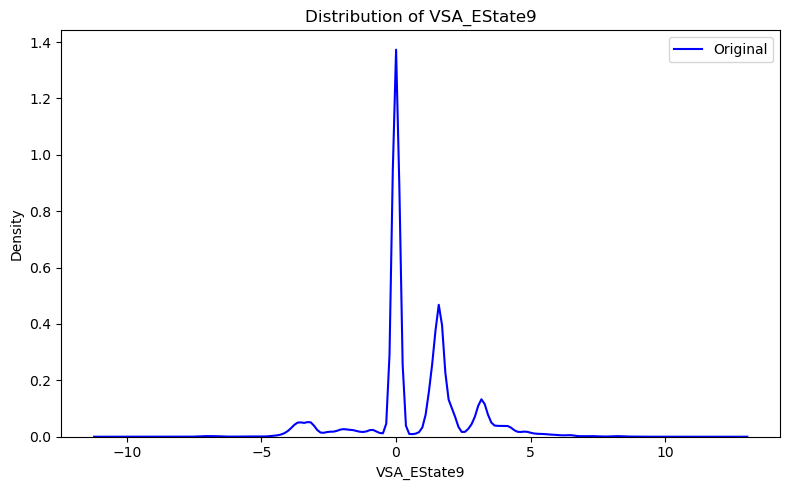

Skewness → Original: 0.55


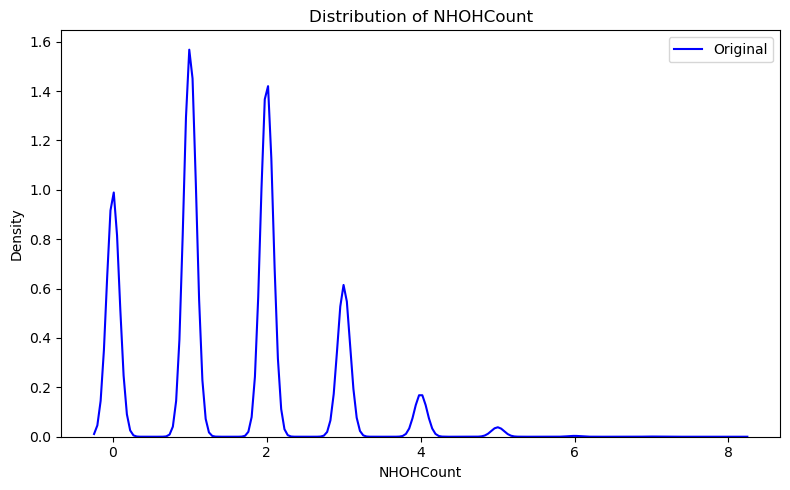

Skewness → Original: 1.52


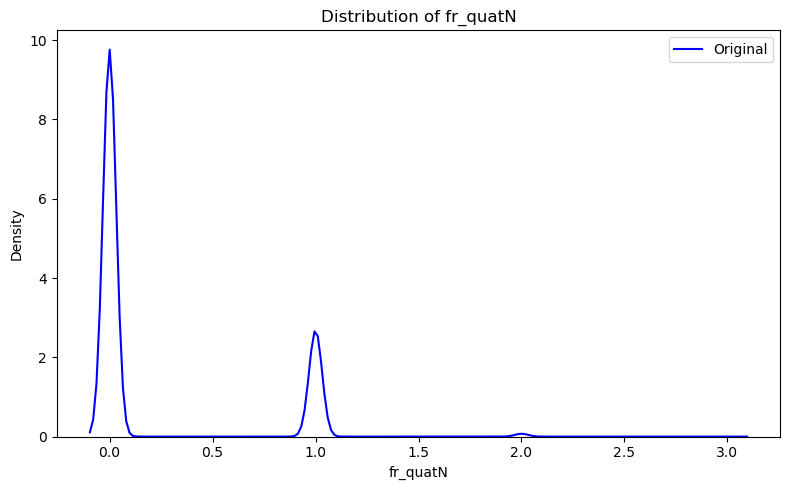

Skewness → Original: -1.15


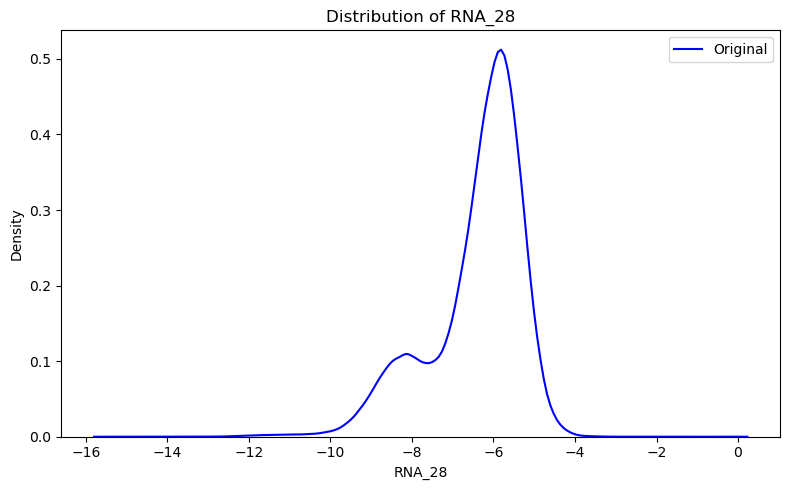

Skewness → Original: 6.11


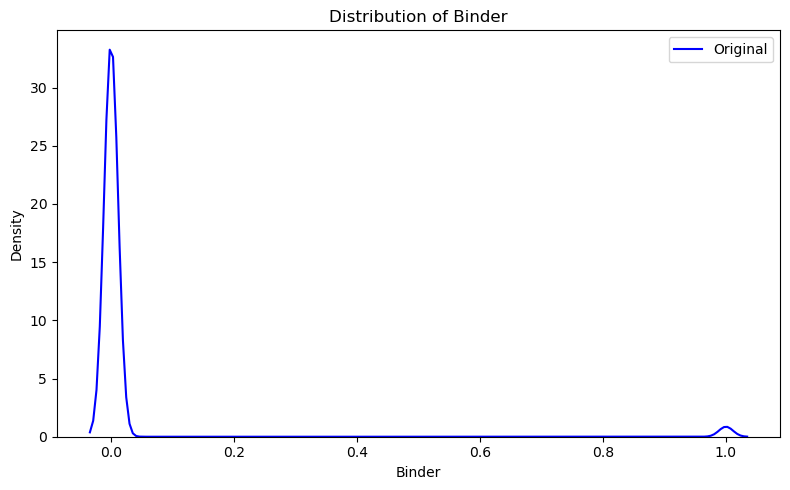

In [226]:
# Plot distributions of the target value and the important features
numeric_cols = df_reduced.select_dtypes(include=['number']).columns
for col in numeric_cols:
    plot_feature_distribution(df_reduced, feature=col)

In [229]:
# Function for Yeo-Johnson transformation of the skewed data
def yeo_johnson_transform(df, target_col, important_features):
    
    transformed_df = df.copy()
    transformers = {}

    columns_to_transform = [target_col] + important_features

    for col in columns_to_transform:
        pt = PowerTransformer(method='yeo-johnson')
        reshaped = df[[col]].values  # keep 2D shape
        transformed = pt.fit_transform(reshaped)
        transformed_df[col] = transformed
        transformers[col] = pt

    return transformed_df, transformers

Skewness → Original: 0.05


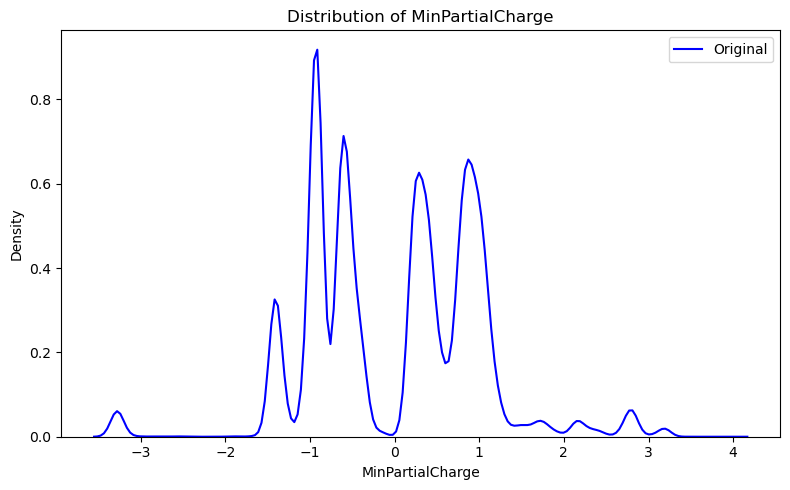

Skewness → Original: -0.05


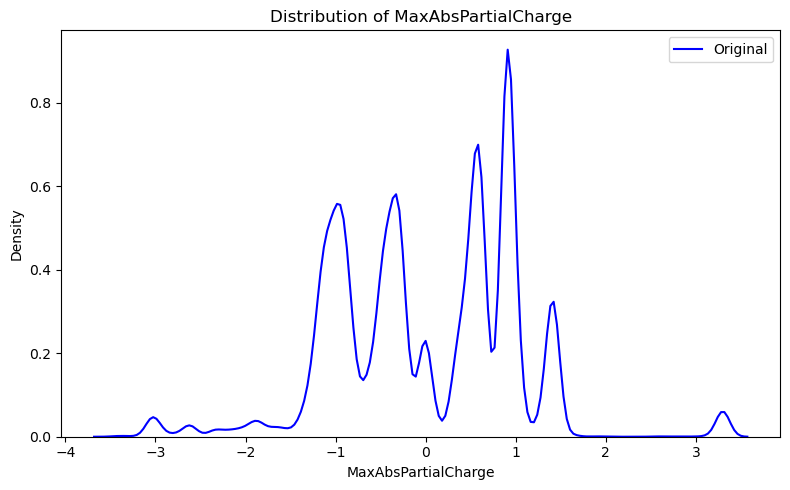

Skewness → Original: -0.89


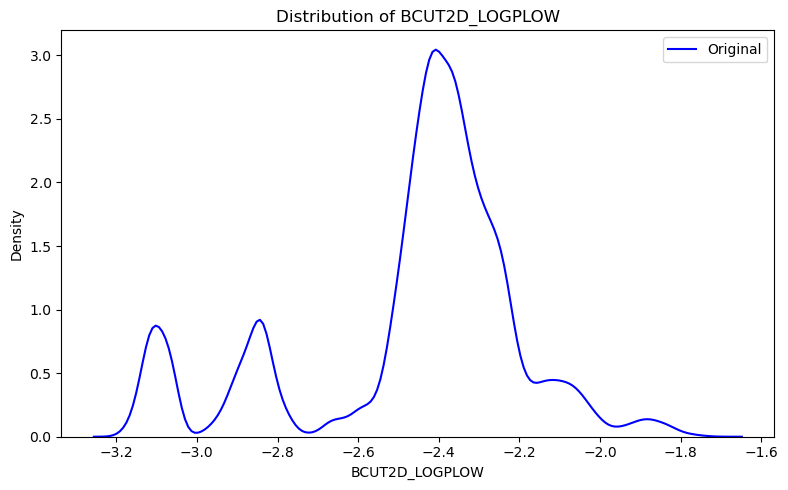

Skewness → Original: -0.34


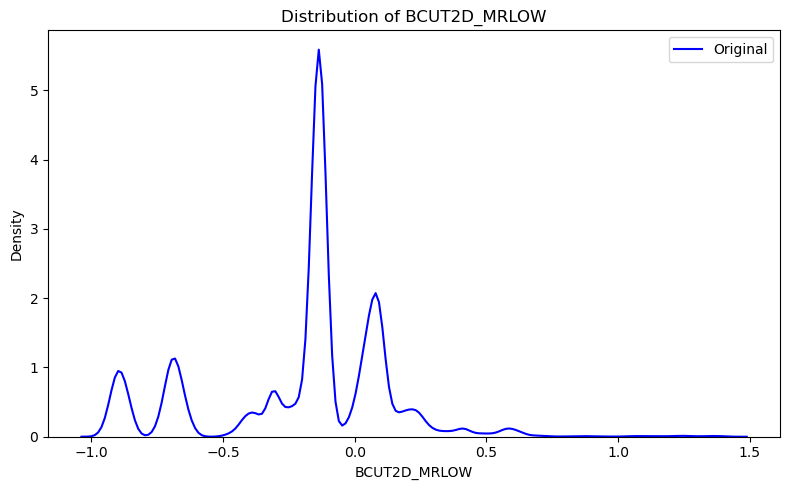

Skewness → Original: 0.75


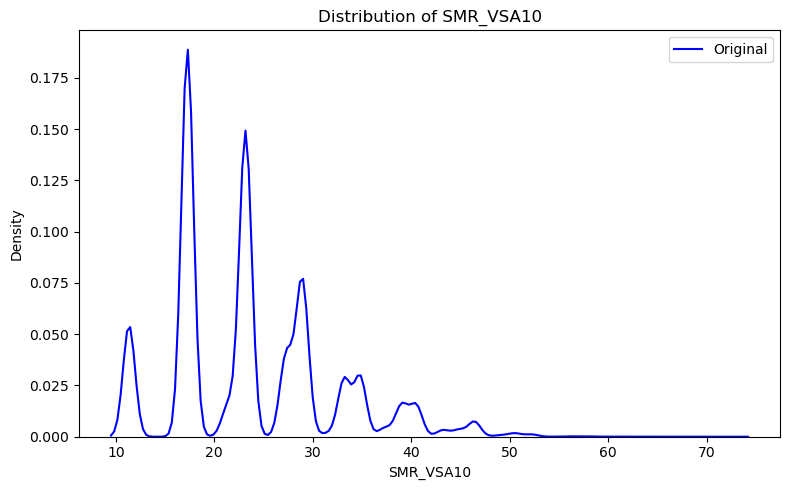

Skewness → Original: 0.39


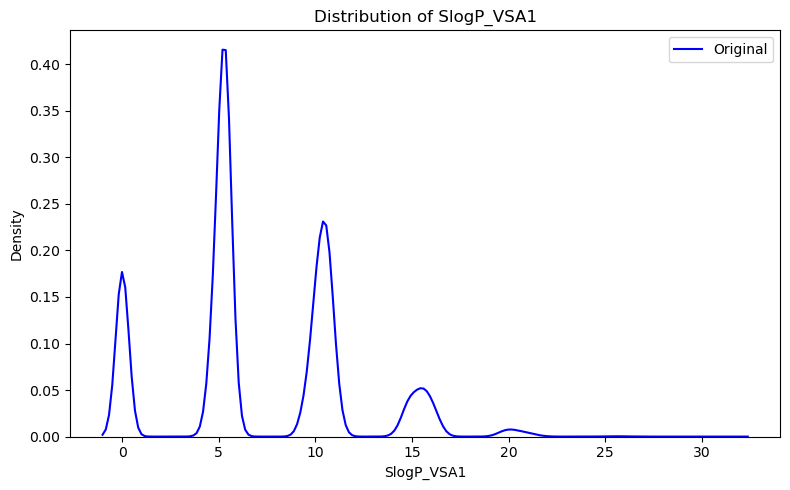

Skewness → Original: 0.27


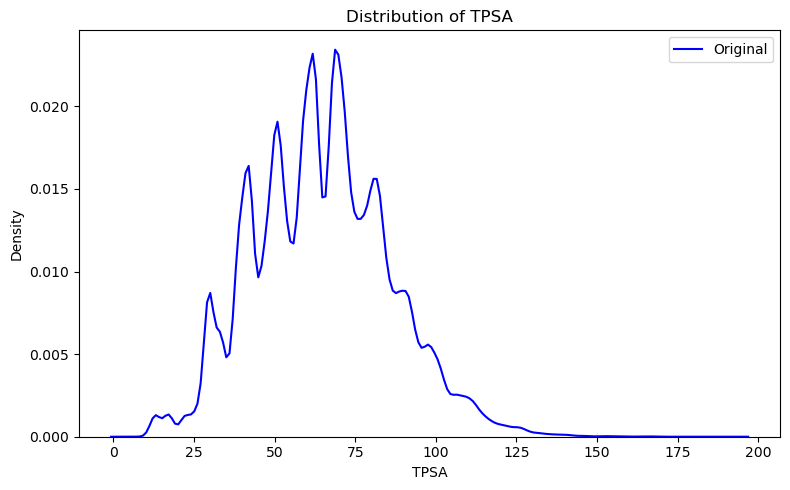

Skewness → Original: -0.10


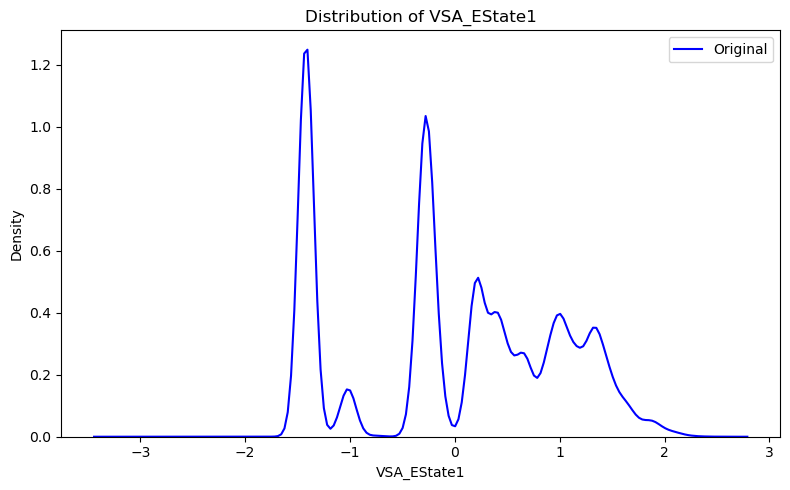

Skewness → Original: -0.01


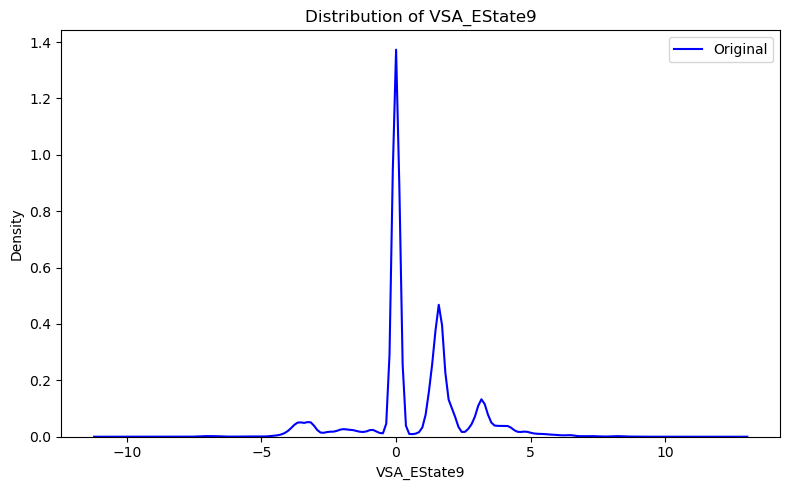

Skewness → Original: 0.55


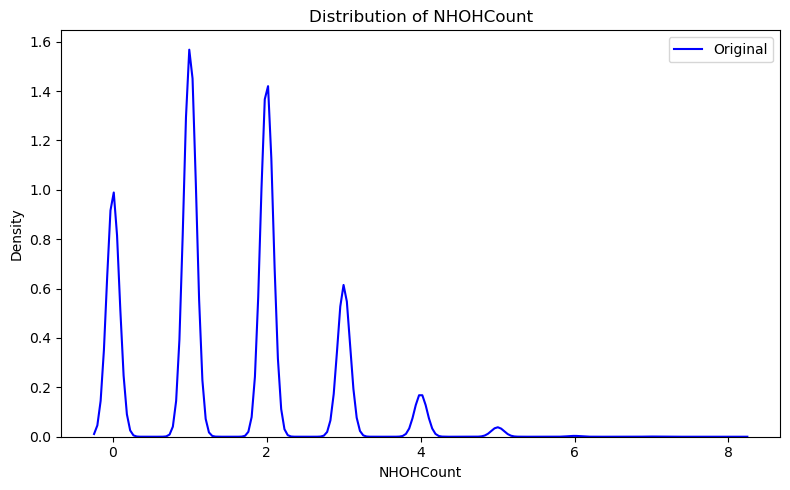

Skewness → Original: 1.52


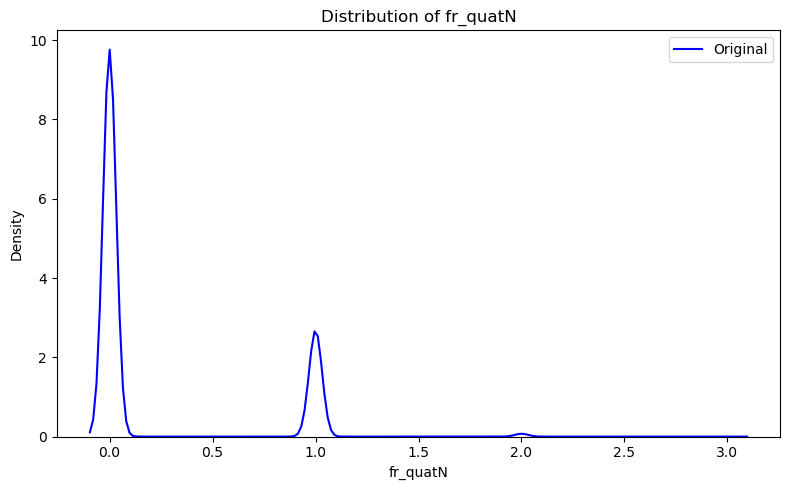

Skewness → Original: 0.31


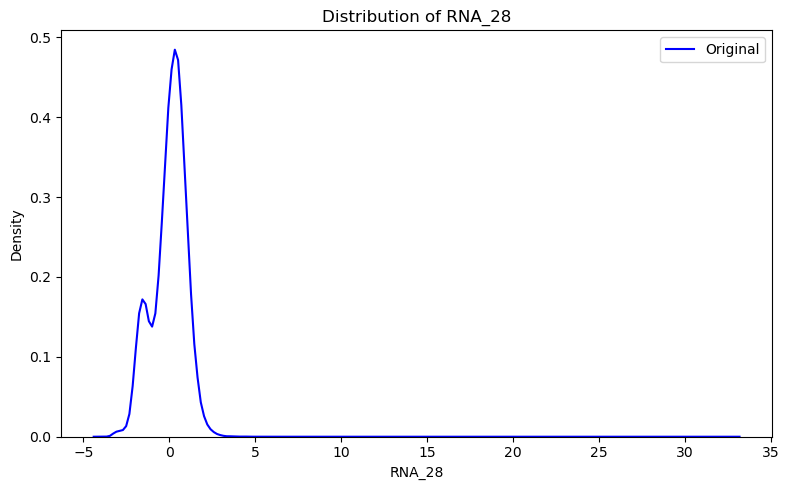

Skewness → Original: 6.11


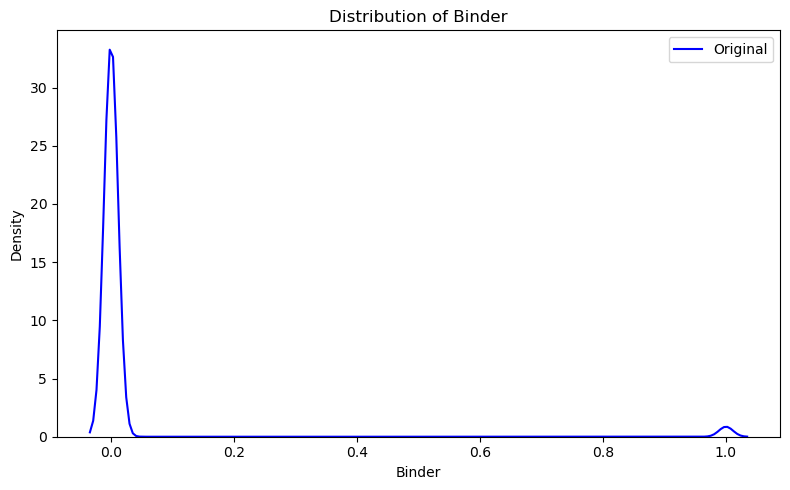

In [230]:
# Apply the  Yeo-Johnson transformation on the skewed target and features
skewed_features = ['MinPartialCharge', 'MaxAbsPartialCharge', 'VSA_EState1']
df_transformed,transformers = yeo_johnson_transform(df_reduced,'RNA_28',skewed_features)
# Plot distributions of the transformed data
numeric_cols = df_transformed.select_dtypes(include=['number']).columns
for col in numeric_cols:
    plot_feature_distribution(df_transformed, feature=col)

In [233]:
# Functions for the subset creation

def create_stratified_subset(df,target_col,important_features,fraction=0.01,q_bins=10,min_class_count=2,random_state=42):

    df_copy = df.copy()

    # Bin target and important features
    df_copy['target_bin'] = pd.qcut(df_copy[target_col], q=q_bins, duplicates='drop')
    for i, feature in enumerate(important_features):
        df_copy[f'feature_bin_{i}'] = pd.qcut(df_copy[feature], q=q_bins, duplicates='drop')

    # Combine into one stratification column
    strat_cols = ['target_bin'] + [f'feature_bin_{i}' for i in range(len(important_features))]
    df_copy['stratify_col'] = df_copy[strat_cols].astype(str).agg('_'.join, axis=1)

    # Remove strata with too few samples
    class_counts = df_copy['stratify_col'].value_counts()
    valid_classes = class_counts[class_counts >= min_class_count].index
    df_copy = df_copy[df_copy['stratify_col'].isin(valid_classes)]

    # Create the stratified subset
    subset, _ = train_test_split(df_copy,train_size=fraction,stratify=df_copy['stratify_col'],random_state=random_state)

    # Drop helper columns
    drop_cols = strat_cols + ['stratify_col']
    subset_cleaned = subset.drop(columns=drop_cols)
    df_cleaned = df_copy.drop(columns=drop_cols)

    return subset_cleaned, df_cleaned

In [234]:
# Data preprocessing of the subset
def data_preprocessing(df=df_reduced, target='RNA_28', ID='ID', test_size=0.2,random_state=42):
    X = df.drop(columns=target)
    y = df[target]

    # Split to train and test
    x_train, x_test, y_train,y_test = train_test_split(X,y,test_size=test_size, random_state=random_state)
    return x_train, x_test, y_train, y_test

(4576, 13)
                       count   mean    std    min    25%    50%    75%     max
MinPartialCharge    4576.000 -0.001  0.993 -3.330 -0.905  0.211  0.816   3.190
MaxAbsPartialCharge 4576.000  0.002  0.990 -3.424 -0.862 -0.000  0.890   3.350
BCUT2D_LOGPLOW      4576.000 -2.462  0.280 -3.182 -2.502 -2.401 -2.305  -1.734
BCUT2D_MRLOW        4576.000 -0.192  0.338 -0.955 -0.306 -0.137  0.042   1.409
SMR_VSA10           4576.000 24.061  8.373 11.337 17.244 23.213 28.907  59.127
SlogP_VSA1          4576.000  7.166  4.646  0.000  5.107  5.317 10.543  25.214
TPSA                4576.000 64.838 21.232 12.890 49.730 63.250 78.860 192.200
VSA_EState1         4576.000  0.004  0.994 -2.576 -1.019  0.171  0.874   2.400
VSA_EState9         4576.000  0.723  1.803 -7.653  0.000  0.000  1.645  10.046
NHOHCount           4576.000  1.480  1.121  0.000  1.000  1.000  2.000   8.000
fr_quatN            4576.000  0.224  0.430  0.000  0.000  0.000  0.000   2.000
RNA_28              4576.000 -0.002  0.96

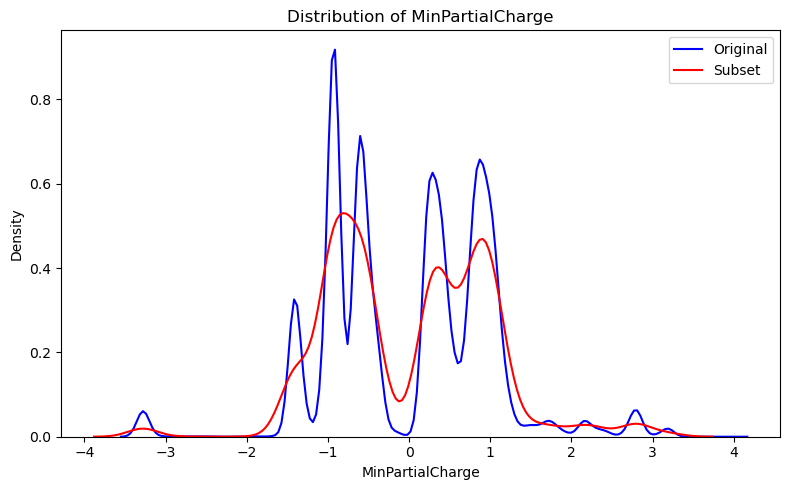

Skewness → Original: -0.05, Subset: -0.17
KS Test → Statistic: 0.0130, p-value: 0.4245
The distributions are similar


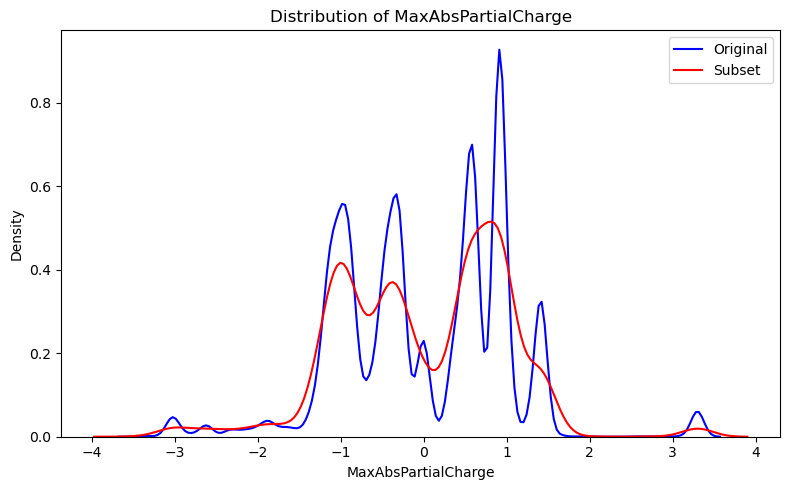

Skewness → Original: -0.89, Subset: -0.89
KS Test → Statistic: 0.0072, p-value: 0.9724
The distributions are similar


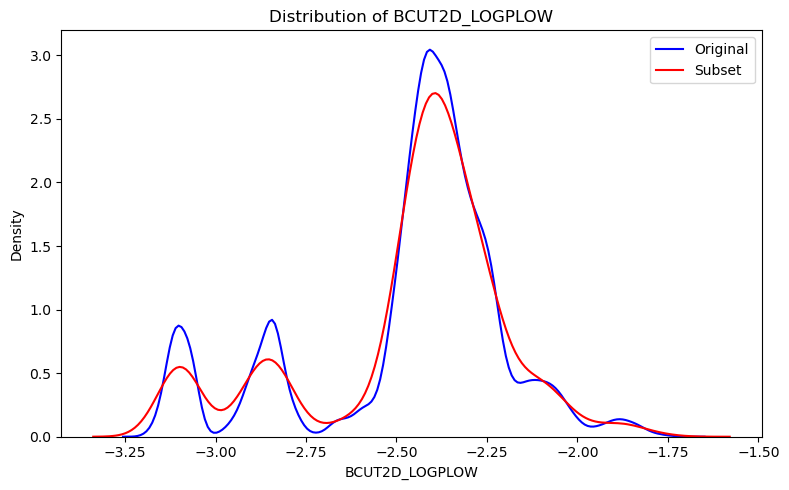

Skewness → Original: -0.34, Subset: -0.36
KS Test → Statistic: 0.0047, p-value: 1.0000
The distributions are similar


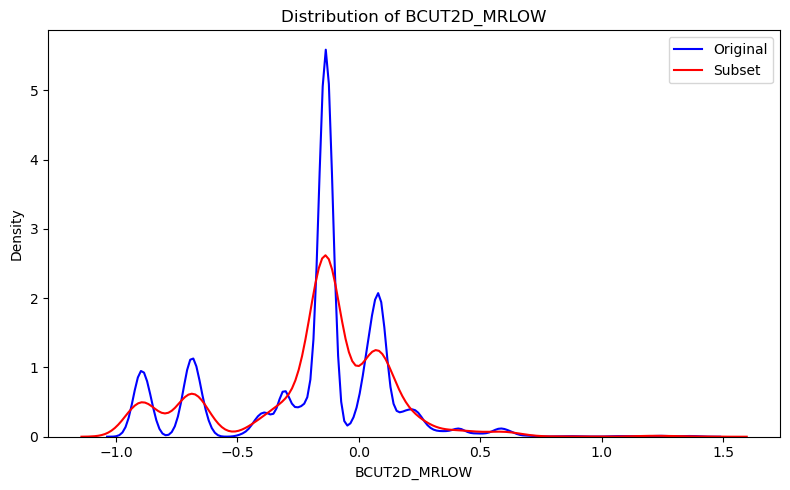

Skewness → Original: 0.75, Subset: 0.74
KS Test → Statistic: 0.0119, p-value: 0.5418
The distributions are similar


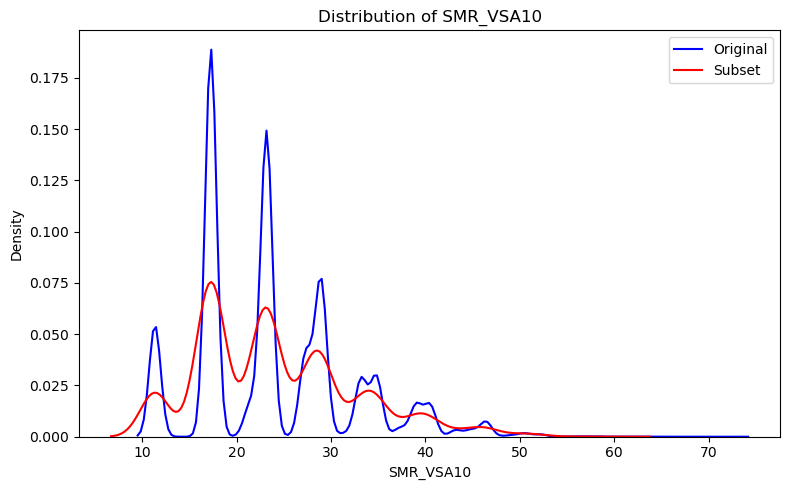

Skewness → Original: 0.39, Subset: 0.35
KS Test → Statistic: 0.0072, p-value: 0.9699
The distributions are similar


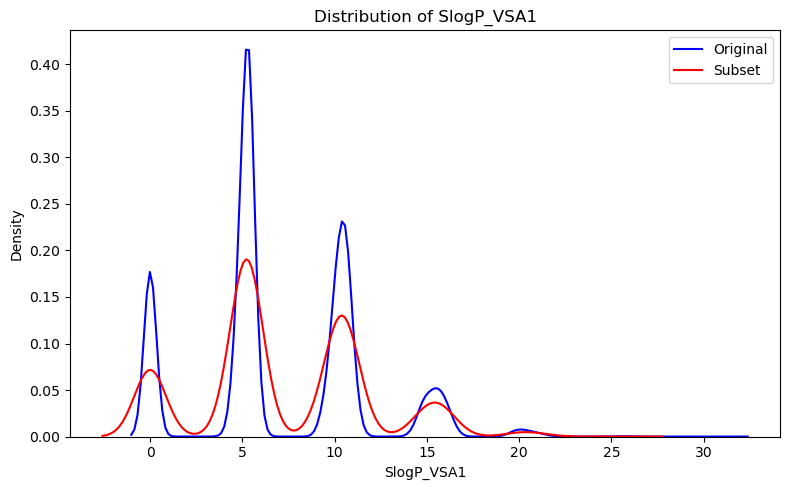

Skewness → Original: 0.27, Subset: 0.33
KS Test → Statistic: 0.0073, p-value: 0.9685
The distributions are similar


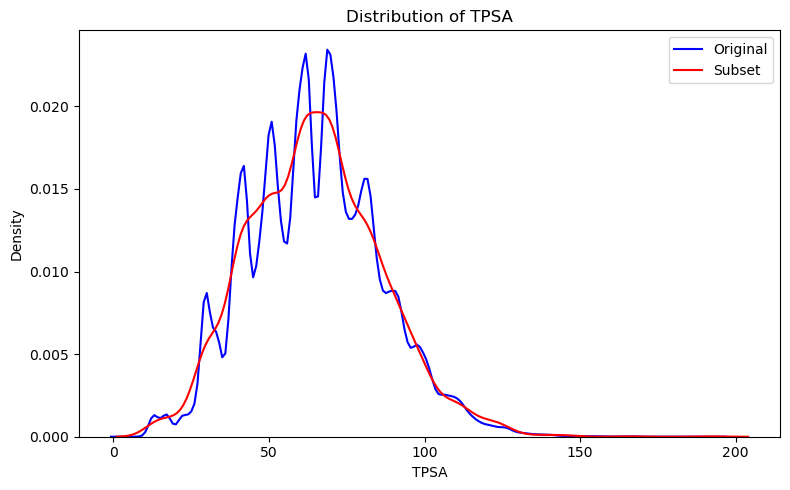

Skewness → Original: -0.10, Subset: -0.13
KS Test → Statistic: 0.0121, p-value: 0.5138
The distributions are similar


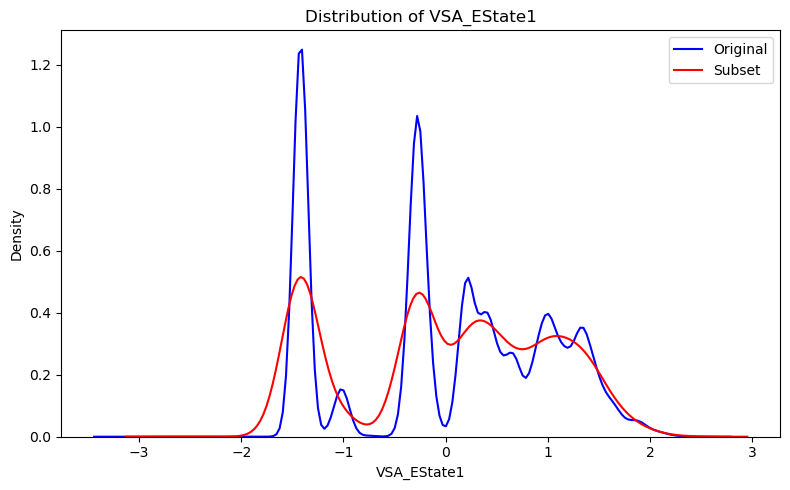

Skewness → Original: -0.01, Subset: 0.06
KS Test → Statistic: 0.0114, p-value: 0.5985
The distributions are similar


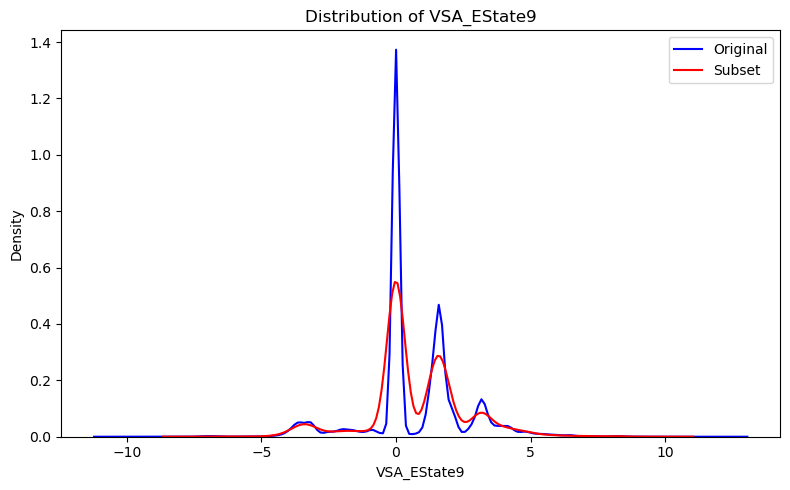

Skewness → Original: 0.55, Subset: 0.60
KS Test → Statistic: 0.0051, p-value: 0.9997
The distributions are similar


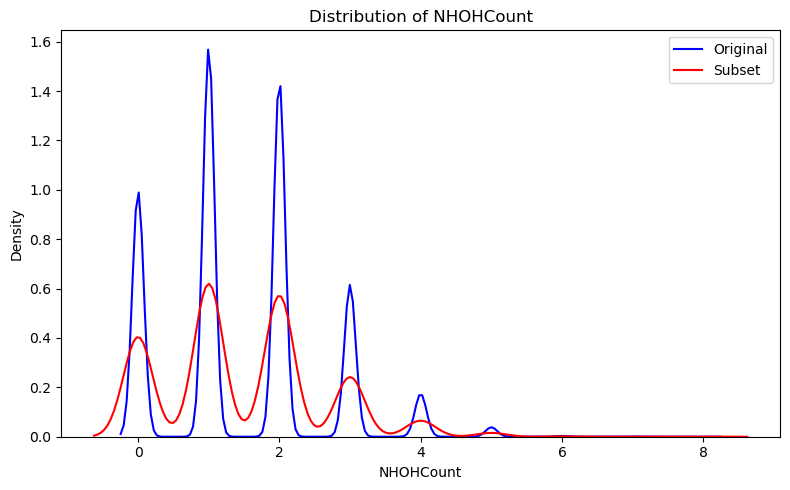

Skewness → Original: 1.52, Subset: 1.54
KS Test → Statistic: 0.0023, p-value: 1.0000
The distributions are similar


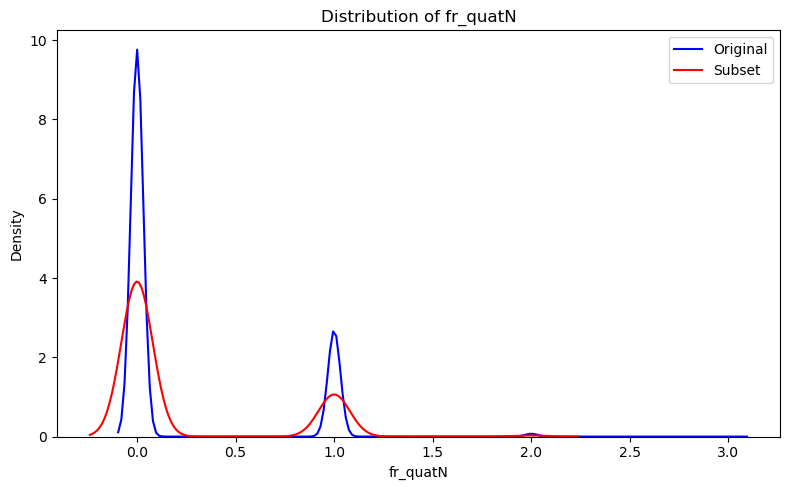

Skewness → Original: 0.31, Subset: -0.48
KS Test → Statistic: 0.0079, p-value: 0.9401
The distributions are similar


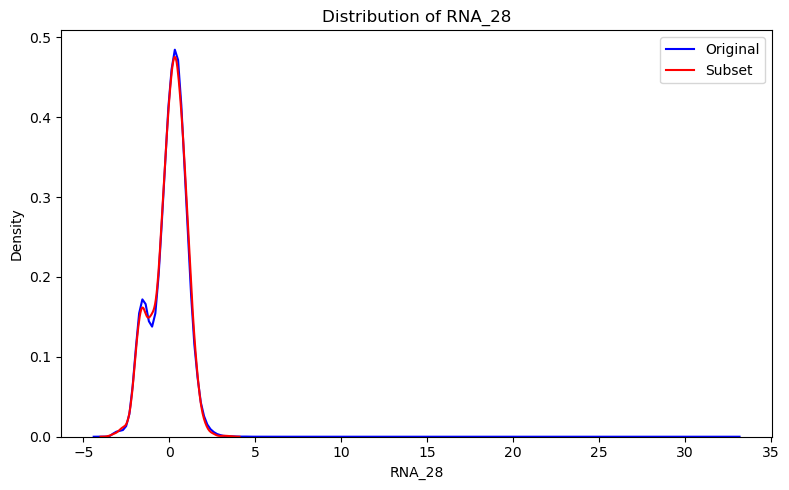

Skewness → Original: 6.11, Subset: 6.37
KS Test → Statistic: 0.0019, p-value: 1.0000
The distributions are similar


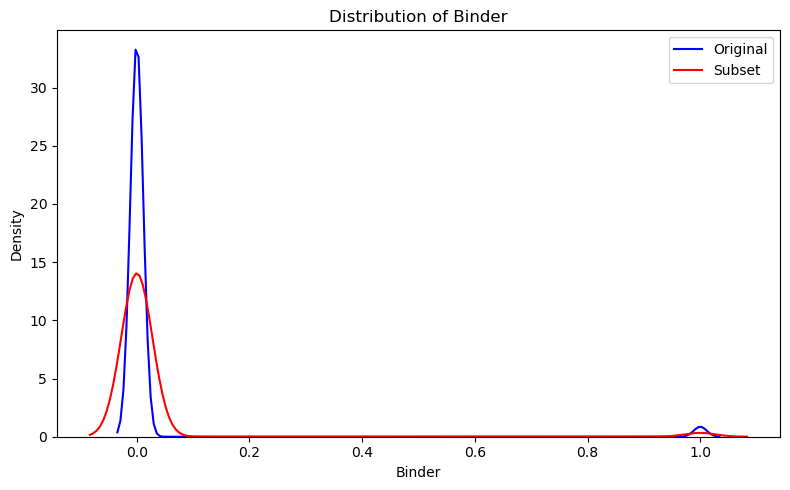

In [238]:
# Create a 1-% subset
subset_1, _ = create_stratified_subset(
    df=df_transformed,
    target_col='RNA_28',
    important_features=['fr_quatN', 'BCUT2D_MRLOW']
)
print(subset_1.shape)
print(subset_1.describe().T)
# Plot distributions of the target value and the important feature

# Filter numeric columns only
numeric_cols = subset_1.select_dtypes(include=['number']).columns
for col in subset_1:
    plot_feature_distribution(df_transformed, feature=col, subset_df=subset_1, subset_feature=col)

In [239]:
# Data preprocessing of the subset 1-%
x_train_1, x_test_1, y_train_1, y_test_1 = data_preprocessing(subset_1)
print(f'Train data shape: {x_train_1.shape}')
print(f'Train target shape: {y_train_1.shape}')
print(f'Test data shape: {x_test_1.shape}')
print(f'Test target shape: {y_test_1.shape}')

Train data shape: (3660, 12)
Train target shape: (3660,)
Test data shape: (916, 12)
Test target shape: (916,)


In [240]:
#The cross validation function
def rmse_cv(model,n_folds=5):
    kf = KFold(n_folds, shuffle=True, random_state=42).get_n_splits(x_train_1)
    rmse= np.sqrt(-cross_val_score(model, x_train_1, y_train_1, scoring="neg_mean_squared_error", cv = kf))
    return(rmse)

In [241]:
# Base models
# Lasso Regression
lasso = make_pipeline(StandardScaler(), Lasso(alpha = 0.0005, random_state=42))
score = rmse_cv(lasso)
print("\nLasso score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))


Lasso score: 0.5483 (0.0089)



In [242]:
# Elastic Net Regression 
ENet = make_pipeline(StandardScaler(), ElasticNet(alpha=0.0008, l1_ratio=1.0, random_state=42))
score = rmse_cv(ENet)
print("\nENet score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))


ENet score: 0.5482 (0.0088)



In [243]:
#XGBoost
model_xgb = xgb.XGBRegressor(n_estimators=366,  learning_rate=0.06, 
                             max_depth=3, subsample=0.7, colsample_bytree=0.96,
                             reg_alpha=4,  reg_lambda=0.8, random_state=42)
score = rmse_cv(model_xgb)
print("\nXGBoost score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))


XGBoost score: 0.4655 (0.0164)



In [244]:
# LightGBM
lgb_reg = lgb.LGBMRegressor(n_estimators=860, learning_rate=0.007,
                         max_depth=12, num_leaves=15,  
                         min_child_samples=15, min_split_gain=0.0,  
                         subsample=0.85, colsample_bytree=0.7,
                         random_state=42,force_col_wise=True)
score = rmse_cv(lgb_reg)
print("\nLightGBM score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))

[LightGBM] [Info] Total Bins 2075
[LightGBM] [Info] Number of data points in the train set: 2928, number of used features: 12
[LightGBM] [Info] Start training from score 0.007290
[LightGBM] [Info] Total Bins 2072
[LightGBM] [Info] Number of data points in the train set: 2928, number of used features: 12
[LightGBM] [Info] Start training from score 0.005948
[LightGBM] [Info] Total Bins 2067
[LightGBM] [Info] Number of data points in the train set: 2928, number of used features: 12
[LightGBM] [Info] Start training from score -0.008922
[LightGBM] [Info] Total Bins 2068
[LightGBM] [Info] Number of data points in the train set: 2928, number of used features: 12
[LightGBM] [Info] Start training from score 0.010664
[LightGBM] [Info] Total Bins 2075
[LightGBM] [Info] Number of data points in the train set: 2928, number of used features: 12
[LightGBM] [Info] Start training from score -0.002155

LightGBM score: 0.4658 (0.0159)



In [245]:
# Define Stacking Averaged Models
class StackingAveragedModels(BaseEstimator, RegressorMixin, TransformerMixin):
    def __init__(self, base_models, meta_model, n_folds=5):
        self.base_models = base_models
        self.meta_model = meta_model
        self.n_folds = n_folds
   
    def fit(self, X, y):
    # Clone base models to avoid altering original models
        self.base_models_ = [list() for _ in self.base_models]
        self.meta_model_ = clone(self.meta_model)
        kfold = KFold(n_splits=self.n_folds, shuffle=True, random_state=156)
    
        # Out-of-fold predictions for meta-model training
        out_of_fold_predictions = np.zeros((X.shape[0], len(self.base_models)))
    
        for i, model in enumerate(self.base_models):
            for train_index, holdout_index in kfold.split(X, y):
               instance = clone(model)
               self.base_models_[i].append(instance)
            
               # Use .iloc for row indexing
               instance.fit(X.iloc[train_index], y.iloc[train_index])
               y_pred = instance.predict(X.iloc[holdout_index])
               out_of_fold_predictions[holdout_index, i] = y_pred
    
        # Fit the meta-model using out-of-fold predictions
        self.meta_model_.fit(out_of_fold_predictions, y)
        return self
   
    def predict(self, X):
        # Meta-features from base models
        meta_features = np.column_stack([
            np.column_stack([model.predict(X) for model in base_models]).mean(axis=1)
            for base_models in self.base_models_
        ])
        return self.meta_model_.predict(meta_features)

# Initialize Stacking Averaged Models
stacked_averaged_models = StackingAveragedModels(base_models = (ENet,lgb_reg,model_xgb),
                                                 meta_model = lasso)

# Perform cross-validation
score = rmse_cv(stacked_averaged_models)
print("Stacking Averaged models score: {:.4f} ({:.4f})".format(score.mean(), score.std()))

[LightGBM] [Info] Total Bins 1993
[LightGBM] [Info] Number of data points in the train set: 2342, number of used features: 12
[LightGBM] [Info] Start training from score 0.022689
[LightGBM] [Info] Total Bins 1993
[LightGBM] [Info] Number of data points in the train set: 2342, number of used features: 12
[LightGBM] [Info] Start training from score -0.003764
[LightGBM] [Info] Total Bins 1992
[LightGBM] [Info] Number of data points in the train set: 2342, number of used features: 12
[LightGBM] [Info] Start training from score 0.012602
[LightGBM] [Info] Total Bins 1989
[LightGBM] [Info] Number of data points in the train set: 2343, number of used features: 12
[LightGBM] [Info] Start training from score -0.001186
[LightGBM] [Info] Total Bins 1992
[LightGBM] [Info] Number of data points in the train set: 2343, number of used features: 12
[LightGBM] [Info] Start training from score 0.006113
[LightGBM] [Info] Total Bins 1990
[LightGBM] [Info] Number of data points in the train set: 2342, numbe

In [246]:
def evaluate_model(model, x_train, x_test, y_train, y_test, target_col, transformer,title='Hexbin Plot: Actual vs. Predicted',
                                     gridsize=50, cmap='viridis', save_path=None):

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    # Ensure y_pred is a NumPy array (it usually is)
    if isinstance(y_pred, pd.Series):
        y_pred = y_pred.to_numpy()
    # Ensure y_test is a NumPy array
    if isinstance(y_test, pd.Series):
        y_test = y_test.to_numpy()

    # Inverse transform the predictions and true values
    y_pred_inv = transformer.inverse_transform(y_pred.reshape(-1, 1))
    y_test_inv = transformer.inverse_transform(y_test.reshape(-1, 1))
    
    plt.figure(figsize=(8, 6))
    hb = plt.hexbin(y_test_inv, y_pred_inv, gridsize=gridsize, cmap=cmap, bins='log')
    plt.plot([y_test_inv.min(), y_test_inv.max()], [y_test_inv.min(), y_test_inv.max()], 'r--', linewidth=1)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(title)
    cb = plt.colorbar(hb)
    cb.set_label('log10(N)')
    plt.grid(True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
        print(f"Hexbin plot saved to {save_path}")
    plt.show()

    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    r2 = r2_score(y_test_inv, y_pred_inv) 
    print(f'The RMSE score is: {rmse:.4f}')
    print(f'The R2 score is: {r2:.4f}')
    return rmse, r2

[LightGBM] [Info] Total Bins 2073
[LightGBM] [Info] Number of data points in the train set: 2928, number of used features: 12
[LightGBM] [Info] Start training from score 0.002333
[LightGBM] [Info] Total Bins 2069
[LightGBM] [Info] Number of data points in the train set: 2928, number of used features: 12
[LightGBM] [Info] Start training from score 0.004112
[LightGBM] [Info] Total Bins 2083
[LightGBM] [Info] Number of data points in the train set: 2928, number of used features: 12
[LightGBM] [Info] Start training from score -0.004218
[LightGBM] [Info] Total Bins 2063
[LightGBM] [Info] Number of data points in the train set: 2928, number of used features: 12
[LightGBM] [Info] Start training from score 0.007172
[LightGBM] [Info] Total Bins 2073
[LightGBM] [Info] Number of data points in the train set: 2928, number of used features: 12
[LightGBM] [Info] Start training from score 0.003426


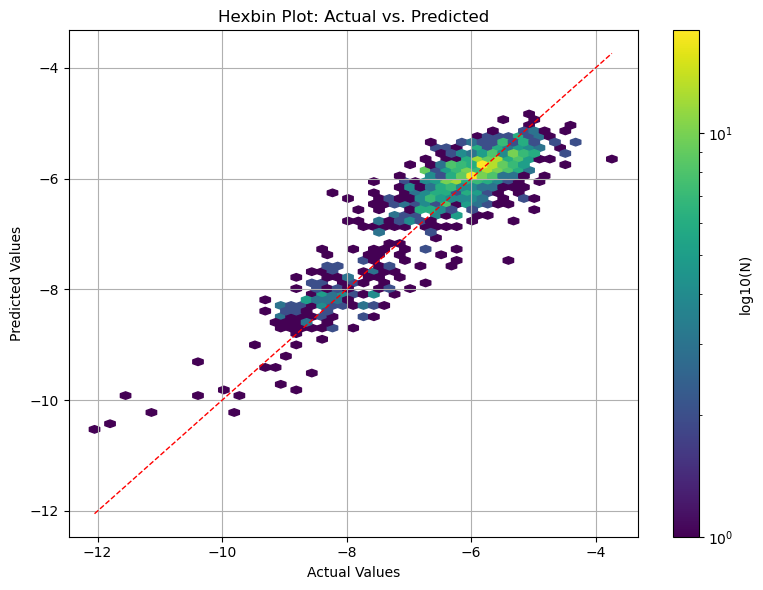

The RMSE score is: 0.4915
The R2 score is: 0.8162


(0.49154115161610307, 0.8161583040622928)

In [247]:
# Evaluate the stacked averaged model on the 1-% subset

evaluate_model(
    model=stacked_averaged_models,
    x_train=x_train_1,x_test=x_test_1,y_train=y_train_1, y_test=y_test_1,
    target_col='RNA_28',
    transformer=transformers['RNA_28']  
)


Train data shape: (366085, 12)
Train target shape: (366085,)
Test data shape: (91522, 12)
Test target shape: (91522,)
[LightGBM] [Info] Total Bins 2073
[LightGBM] [Info] Number of data points in the train set: 2928, number of used features: 12
[LightGBM] [Info] Start training from score 0.002333
[LightGBM] [Info] Total Bins 2069
[LightGBM] [Info] Number of data points in the train set: 2928, number of used features: 12
[LightGBM] [Info] Start training from score 0.004112
[LightGBM] [Info] Total Bins 2083
[LightGBM] [Info] Number of data points in the train set: 2928, number of used features: 12
[LightGBM] [Info] Start training from score -0.004218
[LightGBM] [Info] Total Bins 2063
[LightGBM] [Info] Number of data points in the train set: 2928, number of used features: 12
[LightGBM] [Info] Start training from score 0.007172
[LightGBM] [Info] Total Bins 2073
[LightGBM] [Info] Number of data points in the train set: 2928, number of used features: 12
[LightGBM] [Info] Start training from s

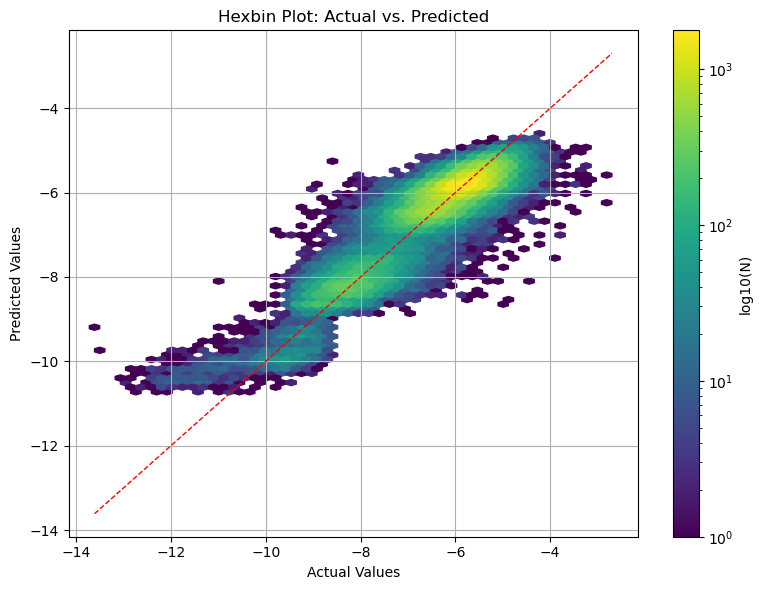

The RMSE score is: 0.4957
The R2 score is: 0.8195


(0.4956586668967086, 0.8195371494532857)

In [248]:
# Evaluate the stacked averaged model on the full dataset while trained on the 1-% subset
# Data preprocessing of the full dataset
x_train, x_test, y_train, y_test = data_preprocessing(df_transformed)
print(f'Train data shape: {x_train.shape}')
print(f'Train target shape: {y_train.shape}')
print(f'Test data shape: {x_test.shape}')
print(f'Test target shape: {y_test.shape}')
evaluate_model(
    model=stacked_averaged_models,
    x_train=x_train_1,x_test=x_test,y_train=y_train_1, y_test=y_test,
    target_col='RNA_28',
    transformer=transformers['RNA_28']  
)

(4576, 13)
                       count   mean    std    min    25%    50%    75%     max
MinPartialCharge    4576.000 -0.001  0.993 -3.330 -0.905  0.211  0.816   3.190
MaxAbsPartialCharge 4576.000  0.002  0.990 -3.424 -0.862 -0.000  0.890   3.350
BCUT2D_LOGPLOW      4576.000 -2.462  0.280 -3.182 -2.502 -2.401 -2.305  -1.734
BCUT2D_MRLOW        4576.000 -0.192  0.338 -0.955 -0.306 -0.137  0.042   1.409
SMR_VSA10           4576.000 24.061  8.373 11.337 17.244 23.213 28.907  59.127
SlogP_VSA1          4576.000  7.166  4.646  0.000  5.107  5.317 10.543  25.214
TPSA                4576.000 64.838 21.232 12.890 49.730 63.250 78.860 192.200
VSA_EState1         4576.000  0.004  0.994 -2.576 -1.019  0.171  0.874   2.400
VSA_EState9         4576.000  0.723  1.803 -7.653  0.000  0.000  1.645  10.046
NHOHCount           4576.000  1.480  1.121  0.000  1.000  1.000  2.000   8.000
fr_quatN            4576.000  0.224  0.430  0.000  0.000  0.000  0.000   2.000
RNA_28              4576.000 -0.002  0.96

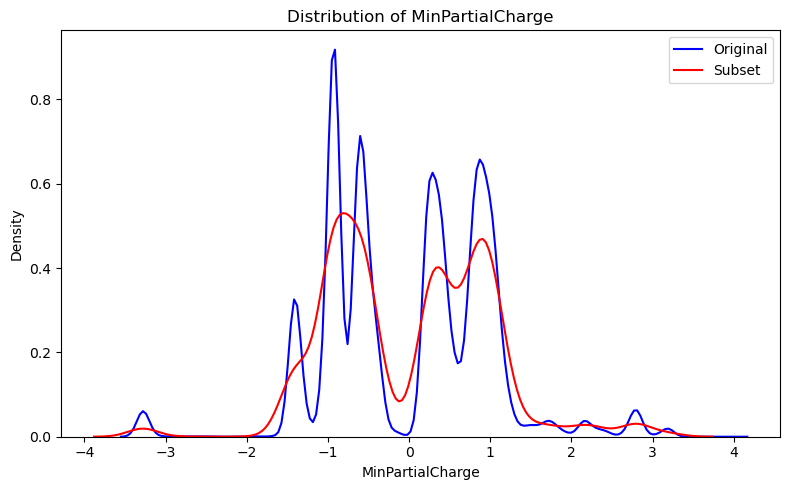

Skewness → Original: -0.05, Subset: -0.17
KS Test → Statistic: 0.0130, p-value: 0.4245
The distributions are similar


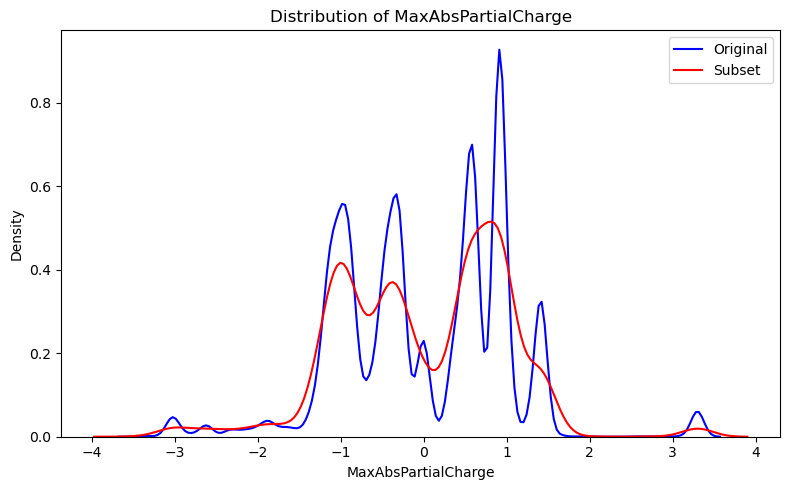

Skewness → Original: -0.89, Subset: -0.89
KS Test → Statistic: 0.0072, p-value: 0.9724
The distributions are similar


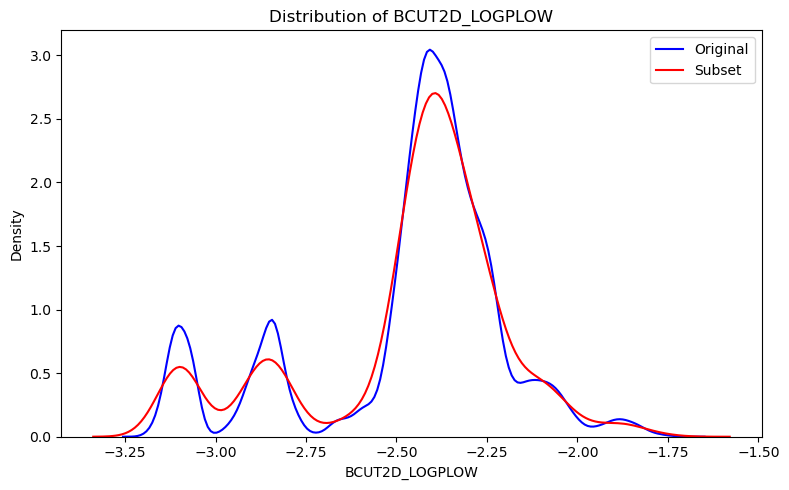

Skewness → Original: -0.34, Subset: -0.36
KS Test → Statistic: 0.0047, p-value: 1.0000
The distributions are similar


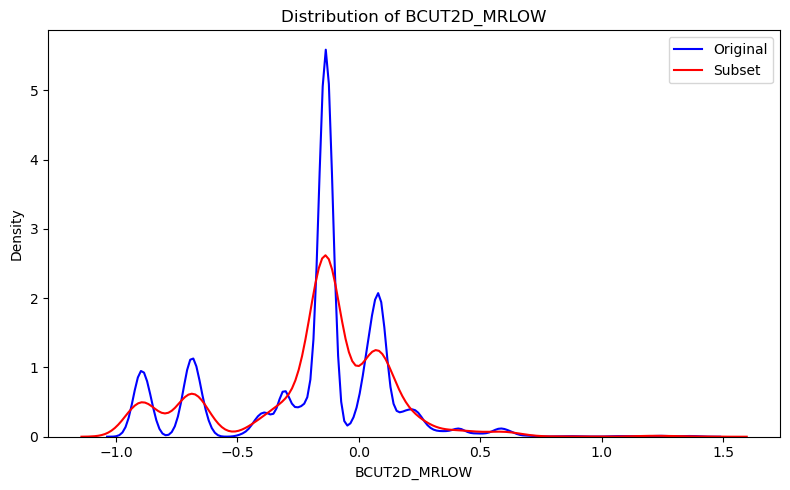

Skewness → Original: 0.75, Subset: 0.74
KS Test → Statistic: 0.0119, p-value: 0.5418
The distributions are similar


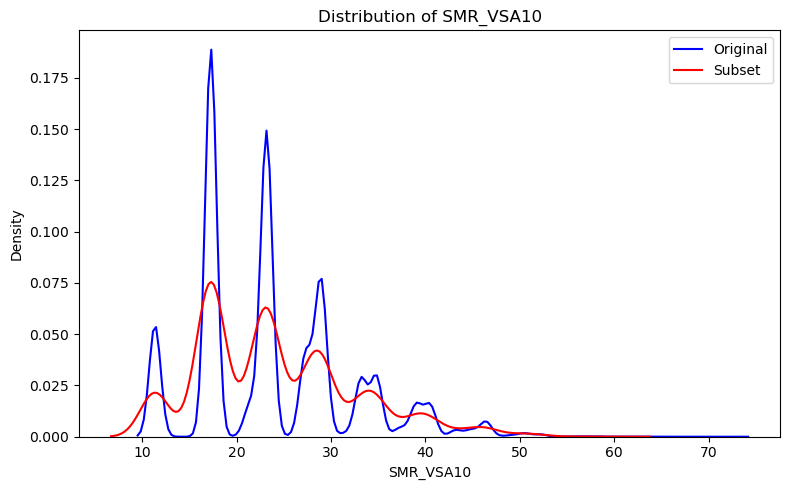

Skewness → Original: 0.39, Subset: 0.35
KS Test → Statistic: 0.0072, p-value: 0.9699
The distributions are similar


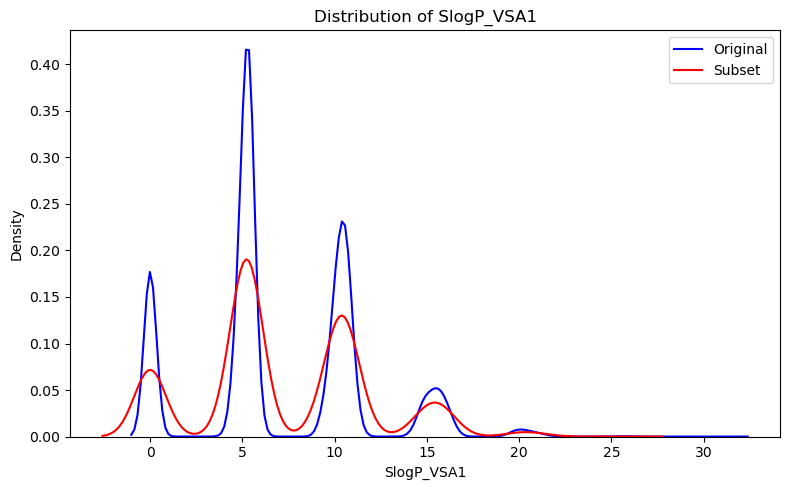

Skewness → Original: 0.27, Subset: 0.33
KS Test → Statistic: 0.0073, p-value: 0.9685
The distributions are similar


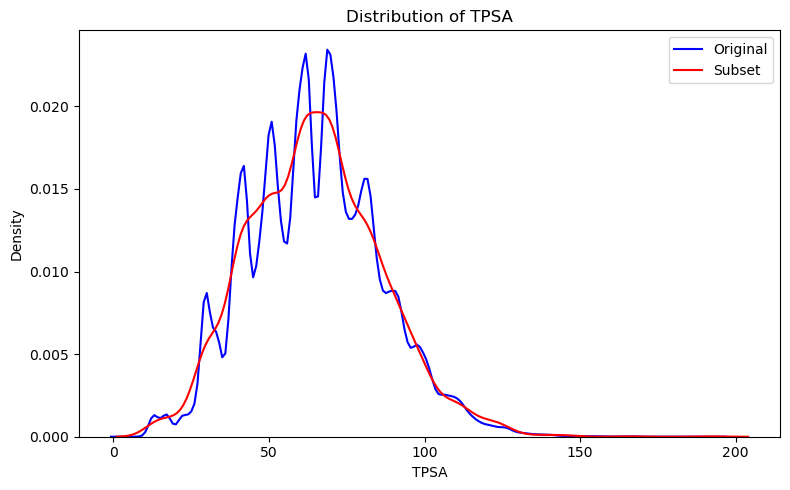

Skewness → Original: -0.10, Subset: -0.13
KS Test → Statistic: 0.0121, p-value: 0.5138
The distributions are similar


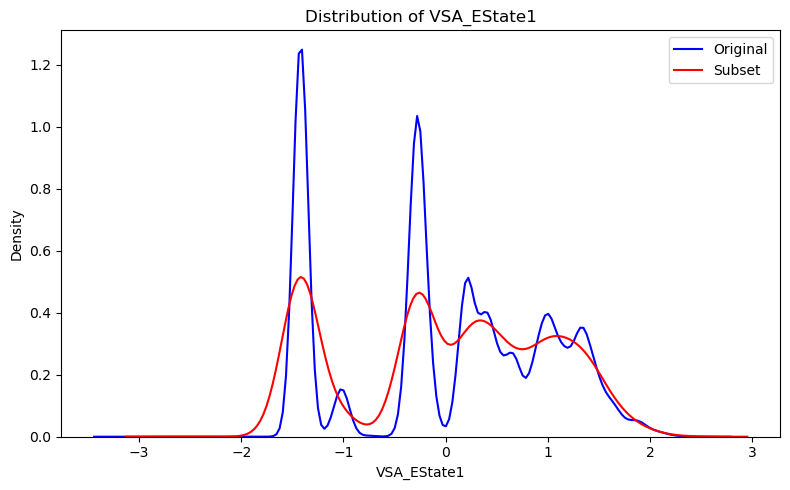

Skewness → Original: -0.01, Subset: 0.06
KS Test → Statistic: 0.0114, p-value: 0.5985
The distributions are similar


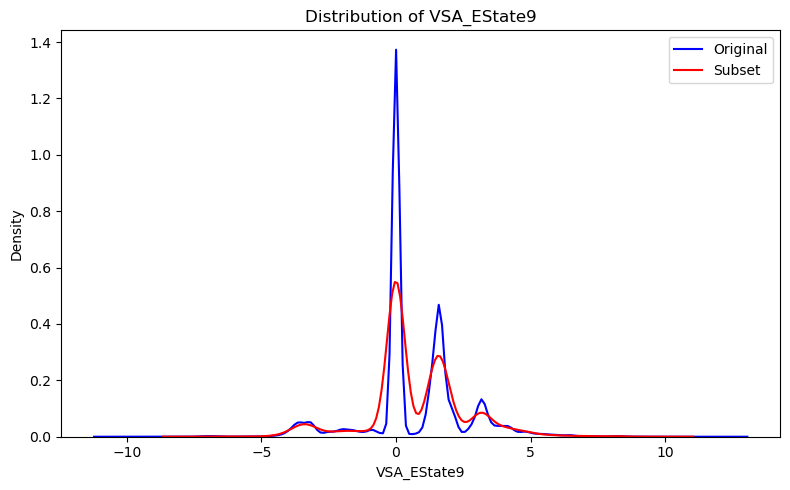

Skewness → Original: 0.55, Subset: 0.60
KS Test → Statistic: 0.0051, p-value: 0.9997
The distributions are similar


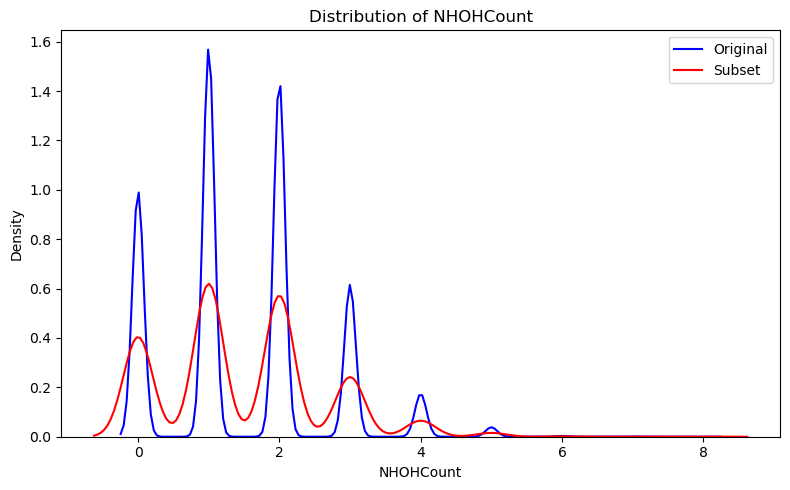

Skewness → Original: 1.52, Subset: 1.54
KS Test → Statistic: 0.0023, p-value: 1.0000
The distributions are similar


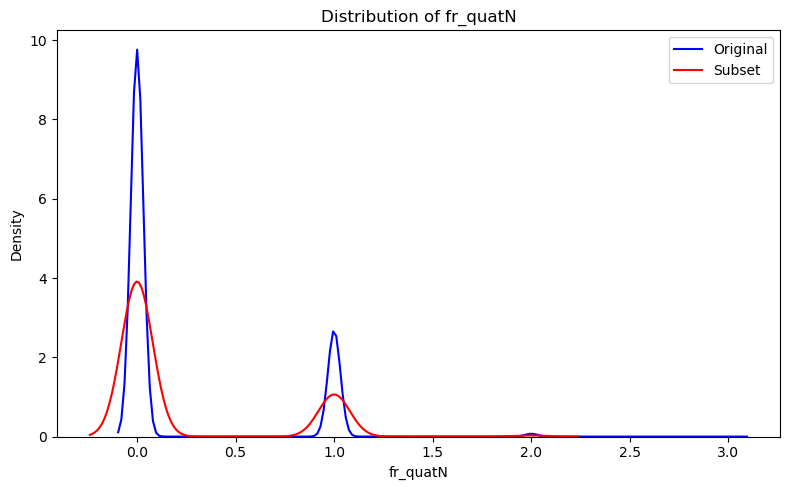

Skewness → Original: 0.31, Subset: -0.48
KS Test → Statistic: 0.0079, p-value: 0.9401
The distributions are similar


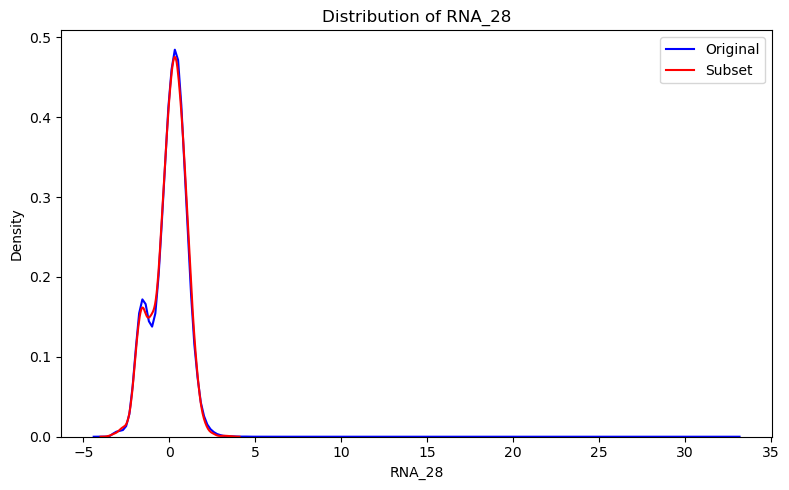

Skewness → Original: 6.11, Subset: 6.37
KS Test → Statistic: 0.0019, p-value: 1.0000
The distributions are similar


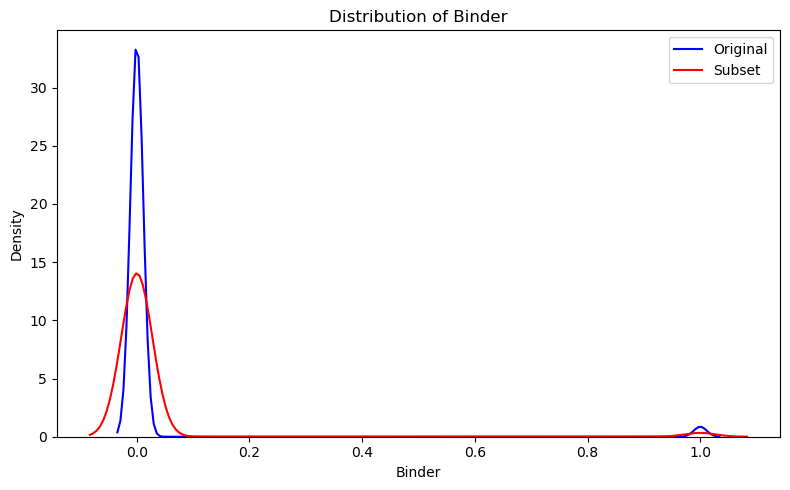

In [249]:
# Create a 2-% subset
subset_2, _ = create_stratified_subset(
    df=df_transformed,fraction=0.02,
    target_col='RNA_28',
    important_features=['fr_quatN', 'BCUT2D_MRLOW']
)
print(subset_1.shape)
print(subset_1.describe().T)
# Plot distributions of the target value and the important feature

# Filter numeric columns only
numeric_cols = subset_1.select_dtypes(include=['number']).columns
for col in subset_1:
    plot_feature_distribution(df_transformed, feature=col, subset_df=subset_1, subset_feature=col)

Train data shape: (7321, 12)
Train target shape: (7321,)
Test data shape: (1831, 12)
Test target shape: (1831,)
[LightGBM] [Info] Total Bins 2114
[LightGBM] [Info] Number of data points in the train set: 5856, number of used features: 12
[LightGBM] [Info] Start training from score -0.001536
[LightGBM] [Info] Total Bins 2111
[LightGBM] [Info] Number of data points in the train set: 5857, number of used features: 12
[LightGBM] [Info] Start training from score 0.002527
[LightGBM] [Info] Total Bins 2107
[LightGBM] [Info] Number of data points in the train set: 5857, number of used features: 12
[LightGBM] [Info] Start training from score -0.006641
[LightGBM] [Info] Total Bins 2110
[LightGBM] [Info] Number of data points in the train set: 5857, number of used features: 12
[LightGBM] [Info] Start training from score -0.005678
[LightGBM] [Info] Total Bins 2103
[LightGBM] [Info] Number of data points in the train set: 5857, number of used features: 12
[LightGBM] [Info] Start training from score

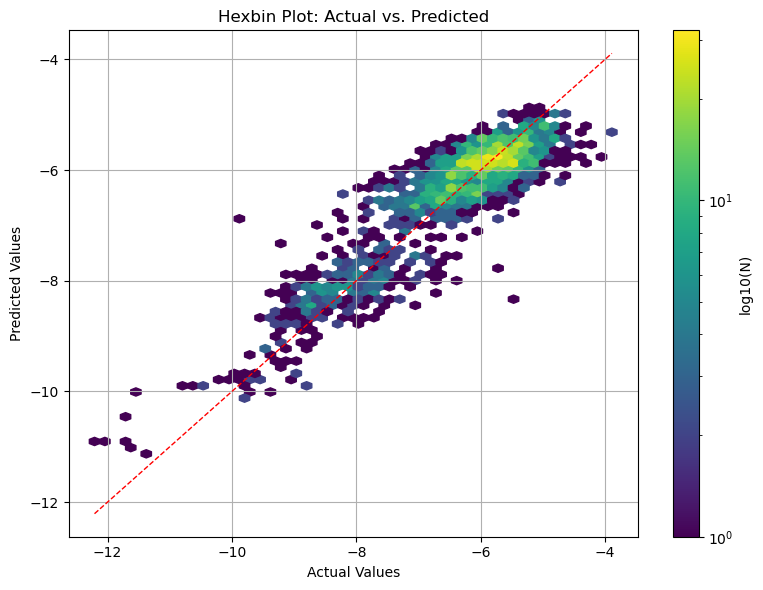

The RMSE score is: 0.5050
The R2 score is: 0.8119


(0.5050008897752581, 0.8118664599393468)

In [250]:
# Evaluate the model on the 2-% subset
# Data preprocessing 
x_train_2, x_test_2, y_train_2, y_test_2 = data_preprocessing(subset_2)
print(f'Train data shape: {x_train_2.shape}')
print(f'Train target shape: {y_train_2.shape}')
print(f'Test data shape: {x_test_2.shape}')
print(f'Test target shape: {y_test_2.shape}')
evaluate_model(
    model=stacked_averaged_models,
    x_train=x_train_2,x_test=x_test_2,y_train=y_train_2, y_test=y_test_2,
    target_col='RNA_28',
    transformer=transformers['RNA_28']  
)

[LightGBM] [Info] Total Bins 2114
[LightGBM] [Info] Number of data points in the train set: 5856, number of used features: 12
[LightGBM] [Info] Start training from score -0.001536
[LightGBM] [Info] Total Bins 2111
[LightGBM] [Info] Number of data points in the train set: 5857, number of used features: 12
[LightGBM] [Info] Start training from score 0.002527
[LightGBM] [Info] Total Bins 2107
[LightGBM] [Info] Number of data points in the train set: 5857, number of used features: 12
[LightGBM] [Info] Start training from score -0.006641
[LightGBM] [Info] Total Bins 2110
[LightGBM] [Info] Number of data points in the train set: 5857, number of used features: 12
[LightGBM] [Info] Start training from score -0.005678
[LightGBM] [Info] Total Bins 2103
[LightGBM] [Info] Number of data points in the train set: 5857, number of used features: 12
[LightGBM] [Info] Start training from score -0.005150


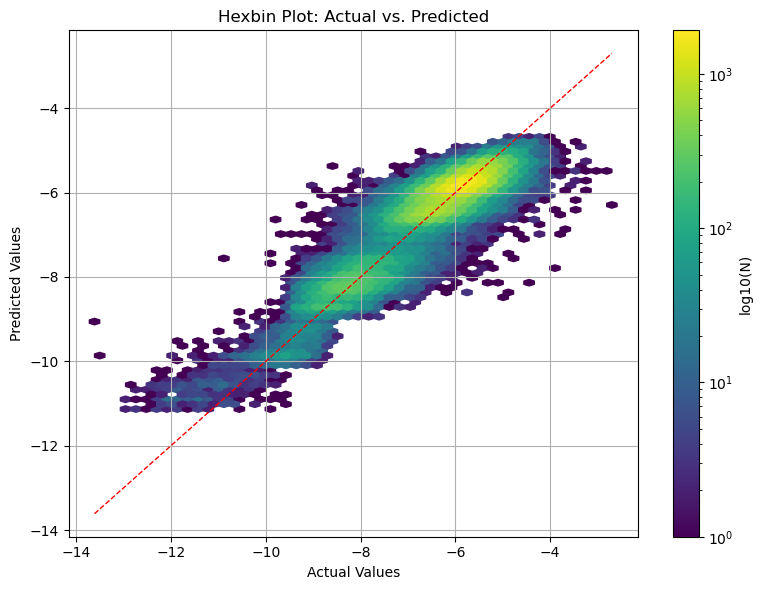

The RMSE score is: 0.4839
The R2 score is: 0.8280


(0.4838927009201015, 0.8280031288599815)

In [251]:
# Evaluate the stacked averaged model on the full dataset while trained on the 2-% subset

evaluate_model(
    model=stacked_averaged_models,
    x_train=x_train_2,x_test=x_test,y_train=y_train_2, y_test=y_test,
    target_col='RNA_28',
    transformer=transformers['RNA_28']  
)

(4576, 13)
                       count   mean    std    min    25%    50%    75%     max
MinPartialCharge    4576.000 -0.001  0.993 -3.330 -0.905  0.211  0.816   3.190
MaxAbsPartialCharge 4576.000  0.002  0.990 -3.424 -0.862 -0.000  0.890   3.350
BCUT2D_LOGPLOW      4576.000 -2.462  0.280 -3.182 -2.502 -2.401 -2.305  -1.734
BCUT2D_MRLOW        4576.000 -0.192  0.338 -0.955 -0.306 -0.137  0.042   1.409
SMR_VSA10           4576.000 24.061  8.373 11.337 17.244 23.213 28.907  59.127
SlogP_VSA1          4576.000  7.166  4.646  0.000  5.107  5.317 10.543  25.214
TPSA                4576.000 64.838 21.232 12.890 49.730 63.250 78.860 192.200
VSA_EState1         4576.000  0.004  0.994 -2.576 -1.019  0.171  0.874   2.400
VSA_EState9         4576.000  0.723  1.803 -7.653  0.000  0.000  1.645  10.046
NHOHCount           4576.000  1.480  1.121  0.000  1.000  1.000  2.000   8.000
fr_quatN            4576.000  0.224  0.430  0.000  0.000  0.000  0.000   2.000
RNA_28              4576.000 -0.002  0.96

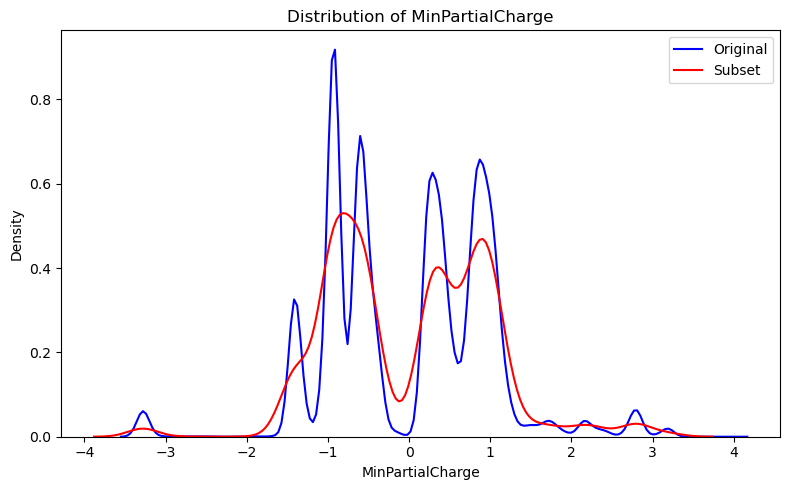

Skewness → Original: -0.05, Subset: -0.17
KS Test → Statistic: 0.0130, p-value: 0.4245
The distributions are similar


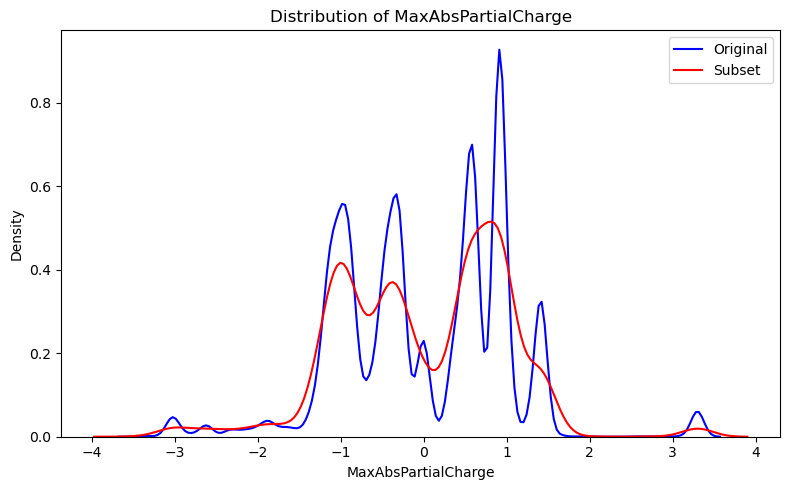

Skewness → Original: -0.89, Subset: -0.89
KS Test → Statistic: 0.0072, p-value: 0.9724
The distributions are similar


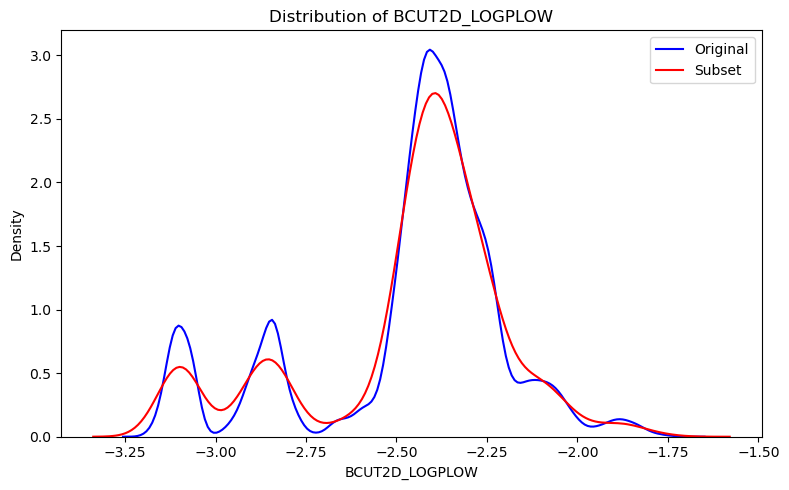

Skewness → Original: -0.34, Subset: -0.36
KS Test → Statistic: 0.0047, p-value: 1.0000
The distributions are similar


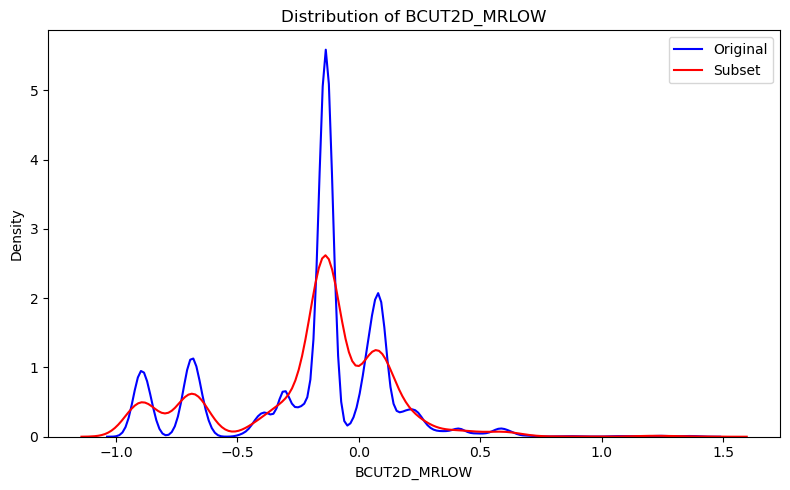

Skewness → Original: 0.75, Subset: 0.74
KS Test → Statistic: 0.0119, p-value: 0.5418
The distributions are similar


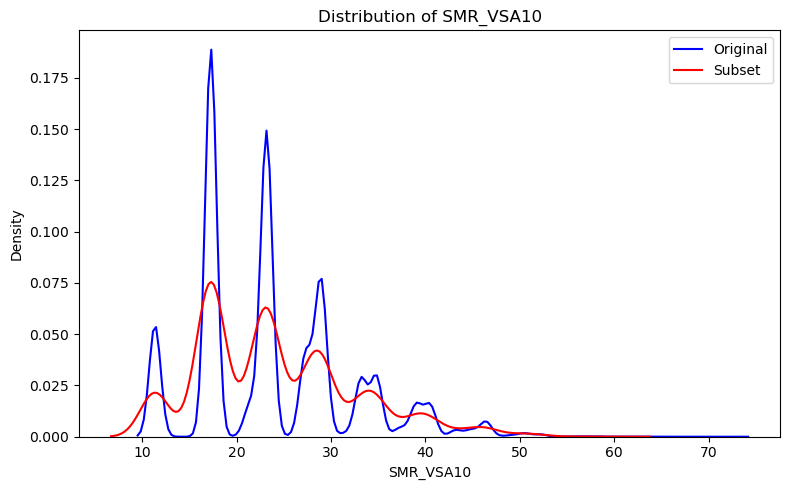

Skewness → Original: 0.39, Subset: 0.35
KS Test → Statistic: 0.0072, p-value: 0.9699
The distributions are similar


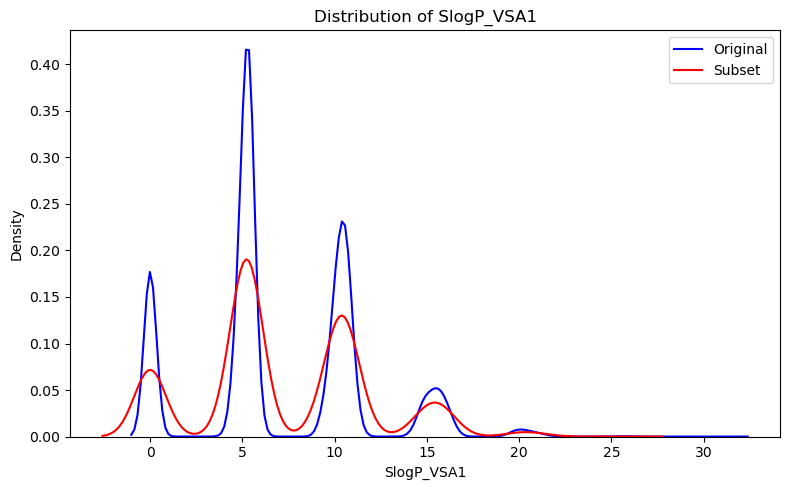

Skewness → Original: 0.27, Subset: 0.33
KS Test → Statistic: 0.0073, p-value: 0.9685
The distributions are similar


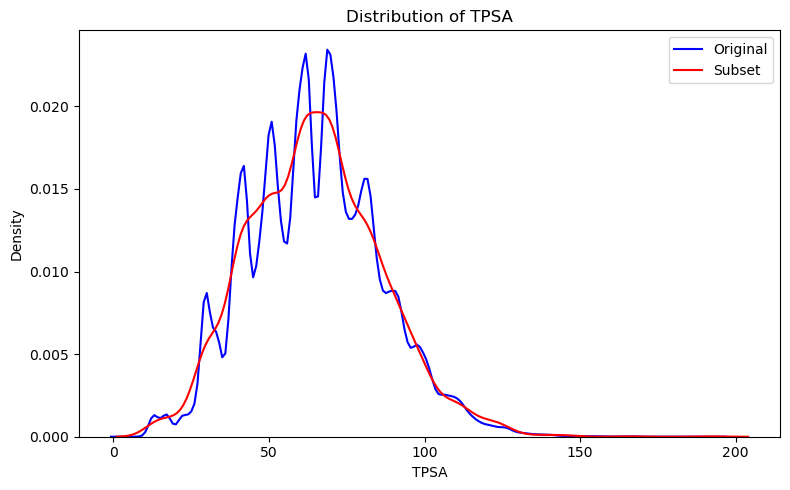

Skewness → Original: -0.10, Subset: -0.13
KS Test → Statistic: 0.0121, p-value: 0.5138
The distributions are similar


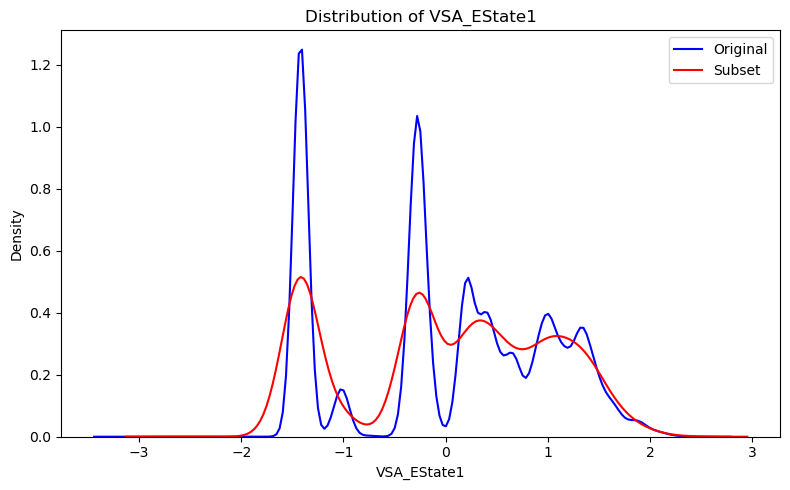

Skewness → Original: -0.01, Subset: 0.06
KS Test → Statistic: 0.0114, p-value: 0.5985
The distributions are similar


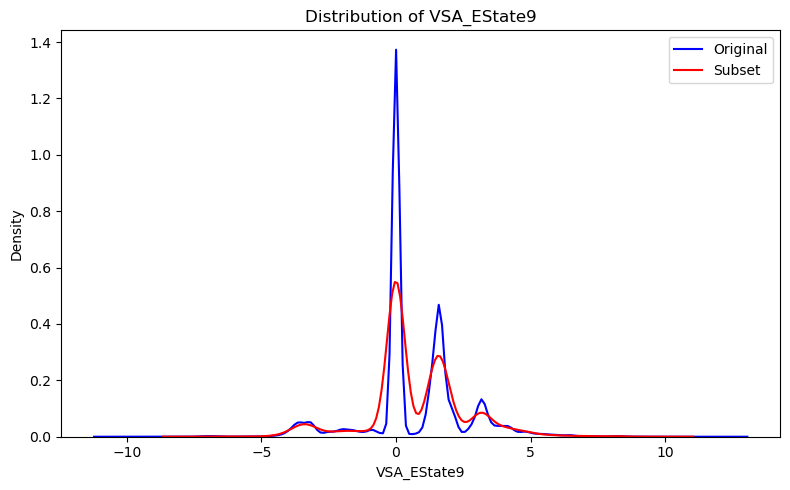

Skewness → Original: 0.55, Subset: 0.60
KS Test → Statistic: 0.0051, p-value: 0.9997
The distributions are similar


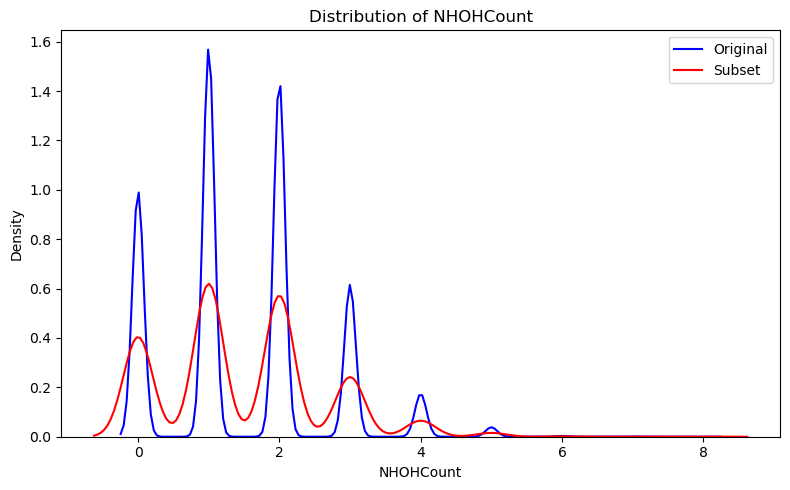

Skewness → Original: 1.52, Subset: 1.54
KS Test → Statistic: 0.0023, p-value: 1.0000
The distributions are similar


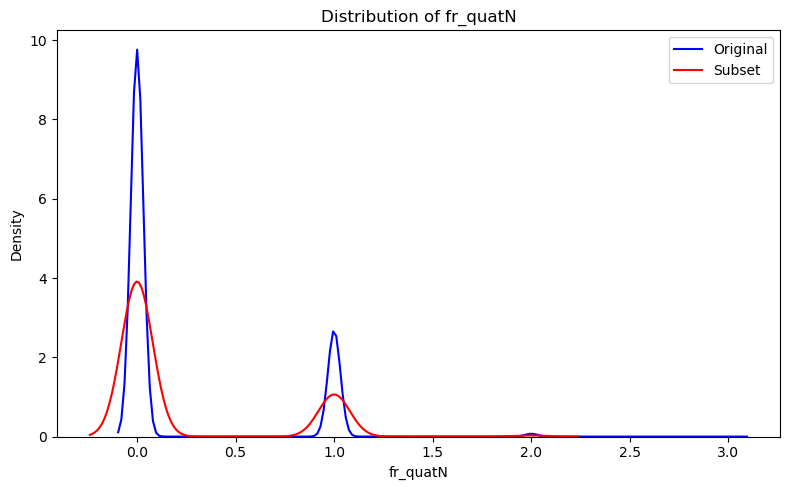

Skewness → Original: 0.31, Subset: -0.48
KS Test → Statistic: 0.0079, p-value: 0.9401
The distributions are similar


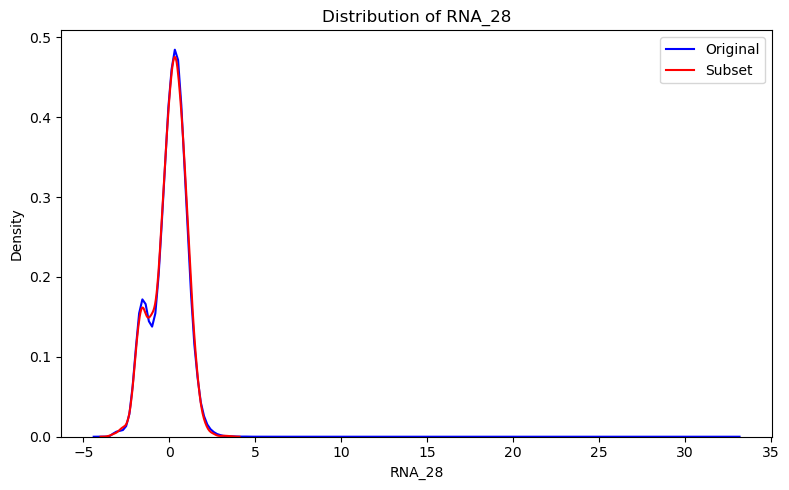

Skewness → Original: 6.11, Subset: 6.37
KS Test → Statistic: 0.0019, p-value: 1.0000
The distributions are similar


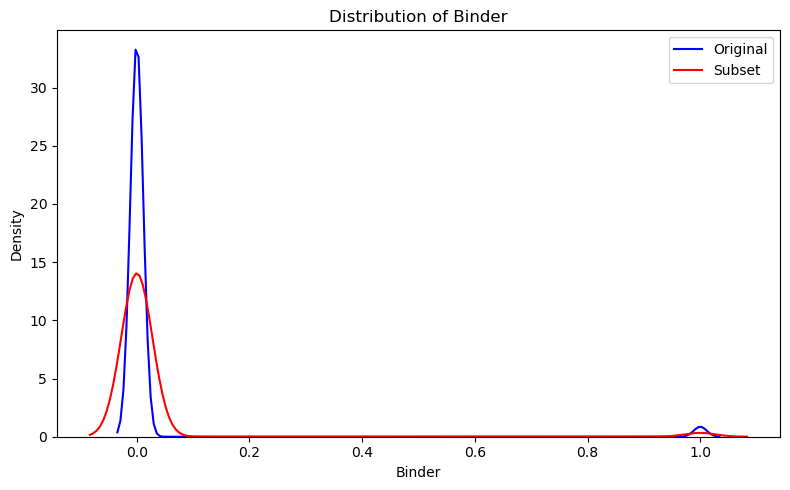

In [252]:
# Create a 3-% subset
subset_3, _ = create_stratified_subset(
    df=df_transformed,fraction=0.03,
    target_col='RNA_28',
    important_features=['fr_quatN', 'BCUT2D_MRLOW']
)
print(subset_1.shape)
print(subset_1.describe().T)
# Plot distributions of the target value and the important feature

# Filter numeric columns only
numeric_cols = subset_1.select_dtypes(include=['number']).columns
for col in subset_1:
    plot_feature_distribution(df_transformed, feature=col, subset_df=subset_1, subset_feature=col)

Train data shape: (10982, 12)
Train target shape: (10982,)
Test data shape: (2746, 12)
Test target shape: (2746,)
[LightGBM] [Info] Total Bins 2134
[LightGBM] [Info] Number of data points in the train set: 8785, number of used features: 12
[LightGBM] [Info] Start training from score -0.004279
[LightGBM] [Info] Total Bins 2139
[LightGBM] [Info] Number of data points in the train set: 8785, number of used features: 12
[LightGBM] [Info] Start training from score 0.000139
[LightGBM] [Info] Total Bins 2144
[LightGBM] [Info] Number of data points in the train set: 8786, number of used features: 12
[LightGBM] [Info] Start training from score -0.001261
[LightGBM] [Info] Total Bins 2141
[LightGBM] [Info] Number of data points in the train set: 8786, number of used features: 12
[LightGBM] [Info] Start training from score -0.000013
[LightGBM] [Info] Total Bins 2132
[LightGBM] [Info] Number of data points in the train set: 8786, number of used features: 12
[LightGBM] [Info] Start training from sco

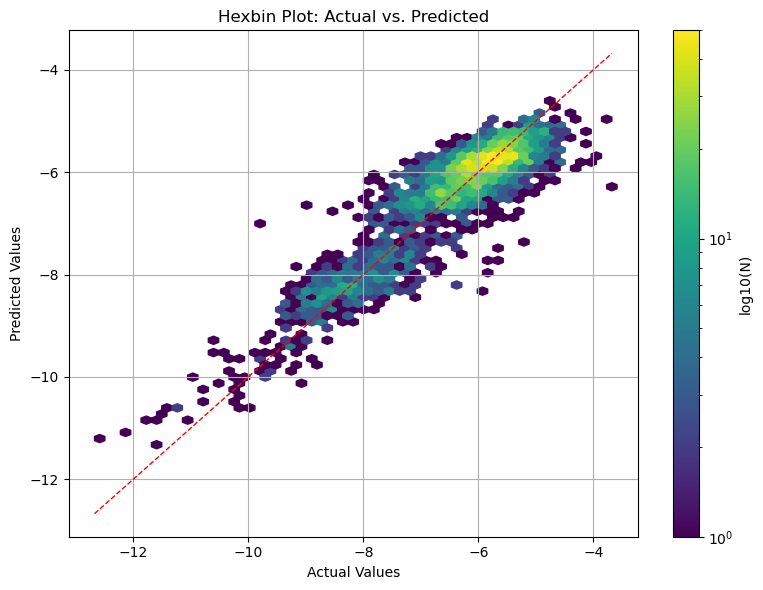

The RMSE score is: 0.4864
The R2 score is: 0.8287


(0.4864486227408855, 0.8286887043623116)

In [253]:
# Evaluate the model on the 3-% subset
# Data preprocessing 
x_train_3, x_test_3, y_train_3, y_test_3 = data_preprocessing(subset_3)
print(f'Train data shape: {x_train_3.shape}')
print(f'Train target shape: {y_train_3.shape}')
print(f'Test data shape: {x_test_3.shape}')
print(f'Test target shape: {y_test_3.shape}')
evaluate_model(
    model=stacked_averaged_models,
    x_train=x_train_3,x_test=x_test_3,y_train=y_train_3, y_test=y_test_3,
    target_col='RNA_28',
    transformer=transformers['RNA_28']  
)

[LightGBM] [Info] Total Bins 2134
[LightGBM] [Info] Number of data points in the train set: 8785, number of used features: 12
[LightGBM] [Info] Start training from score -0.004279
[LightGBM] [Info] Total Bins 2139
[LightGBM] [Info] Number of data points in the train set: 8785, number of used features: 12
[LightGBM] [Info] Start training from score 0.000139
[LightGBM] [Info] Total Bins 2144
[LightGBM] [Info] Number of data points in the train set: 8786, number of used features: 12
[LightGBM] [Info] Start training from score -0.001261
[LightGBM] [Info] Total Bins 2141
[LightGBM] [Info] Number of data points in the train set: 8786, number of used features: 12
[LightGBM] [Info] Start training from score -0.000013
[LightGBM] [Info] Total Bins 2132
[LightGBM] [Info] Number of data points in the train set: 8786, number of used features: 12
[LightGBM] [Info] Start training from score 0.000310


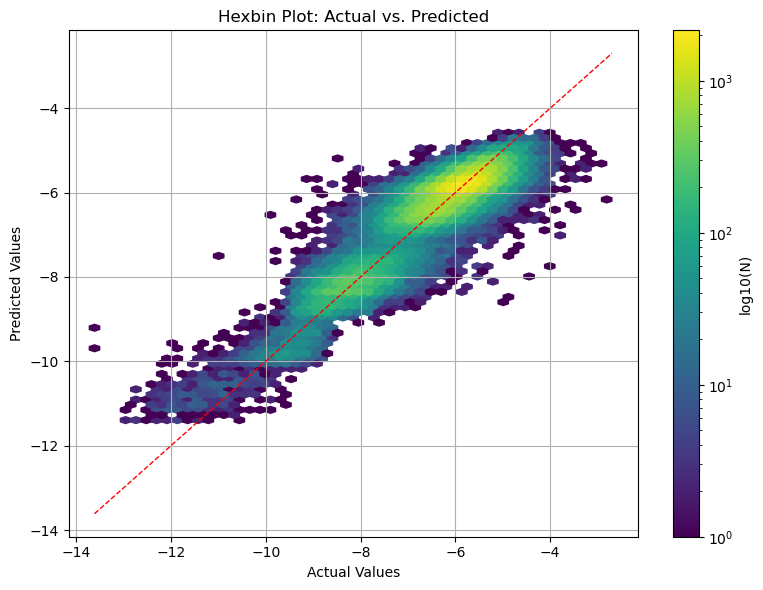

The RMSE score is: 0.4819
The R2 score is: 0.8295


(0.4818503378269593, 0.8294519572396389)

In [254]:
# Evaluate the stacked averaged model on the full dataset while trained on the 3-% subset

evaluate_model(
    model=stacked_averaged_models,
    x_train=x_train_3,x_test=x_test,y_train=y_train_3, y_test=y_test,
    target_col='RNA_28',
    transformer=transformers['RNA_28']  
)

(4576, 13)
                       count   mean    std    min    25%    50%    75%     max
MinPartialCharge    4576.000 -0.001  0.993 -3.330 -0.905  0.211  0.816   3.190
MaxAbsPartialCharge 4576.000  0.002  0.990 -3.424 -0.862 -0.000  0.890   3.350
BCUT2D_LOGPLOW      4576.000 -2.462  0.280 -3.182 -2.502 -2.401 -2.305  -1.734
BCUT2D_MRLOW        4576.000 -0.192  0.338 -0.955 -0.306 -0.137  0.042   1.409
SMR_VSA10           4576.000 24.061  8.373 11.337 17.244 23.213 28.907  59.127
SlogP_VSA1          4576.000  7.166  4.646  0.000  5.107  5.317 10.543  25.214
TPSA                4576.000 64.838 21.232 12.890 49.730 63.250 78.860 192.200
VSA_EState1         4576.000  0.004  0.994 -2.576 -1.019  0.171  0.874   2.400
VSA_EState9         4576.000  0.723  1.803 -7.653  0.000  0.000  1.645  10.046
NHOHCount           4576.000  1.480  1.121  0.000  1.000  1.000  2.000   8.000
fr_quatN            4576.000  0.224  0.430  0.000  0.000  0.000  0.000   2.000
RNA_28              4576.000 -0.002  0.96

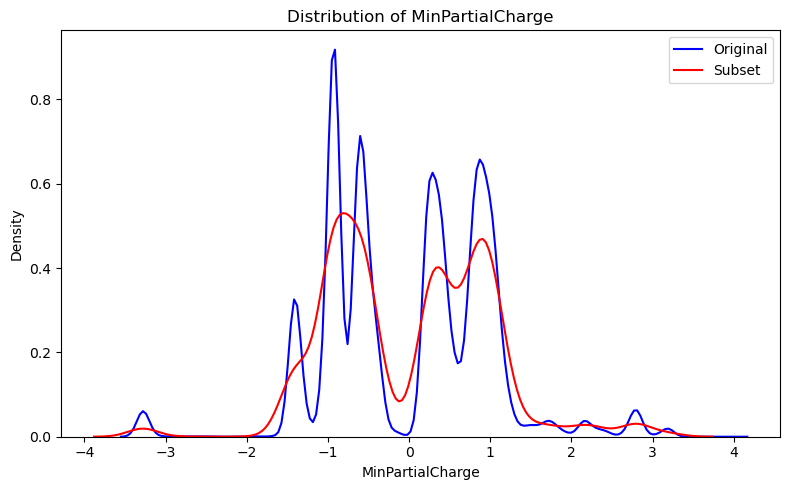

Skewness → Original: -0.05, Subset: -0.17
KS Test → Statistic: 0.0130, p-value: 0.4245
The distributions are similar


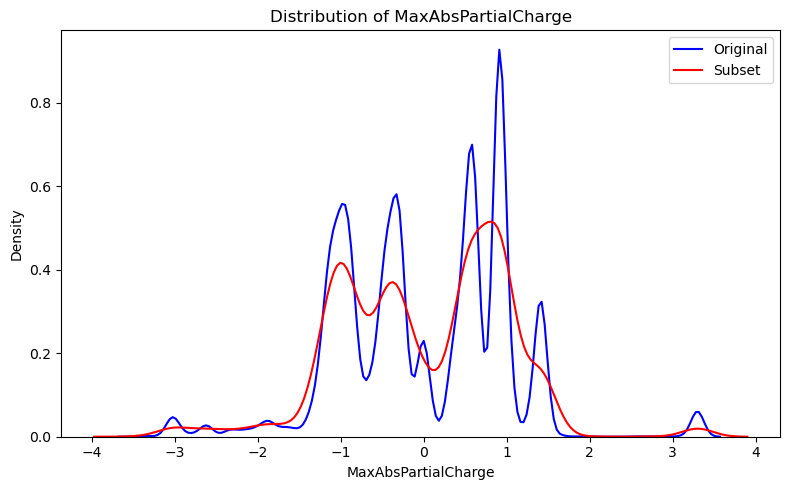

Skewness → Original: -0.89, Subset: -0.89
KS Test → Statistic: 0.0072, p-value: 0.9724
The distributions are similar


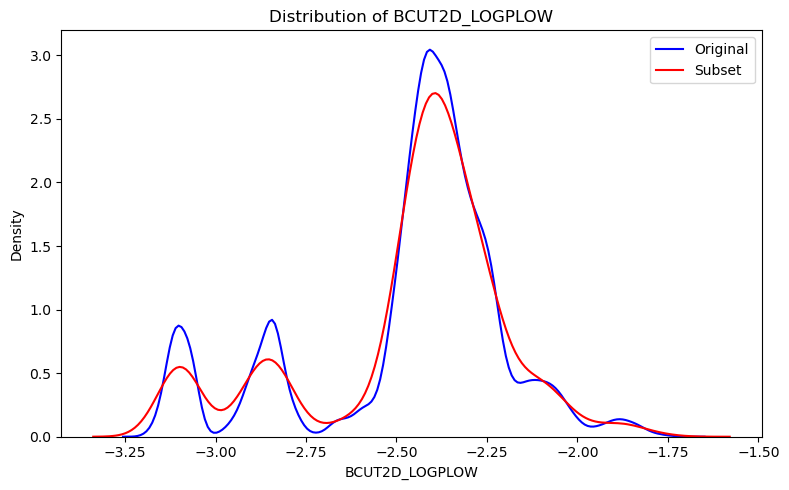

Skewness → Original: -0.34, Subset: -0.36
KS Test → Statistic: 0.0047, p-value: 1.0000
The distributions are similar


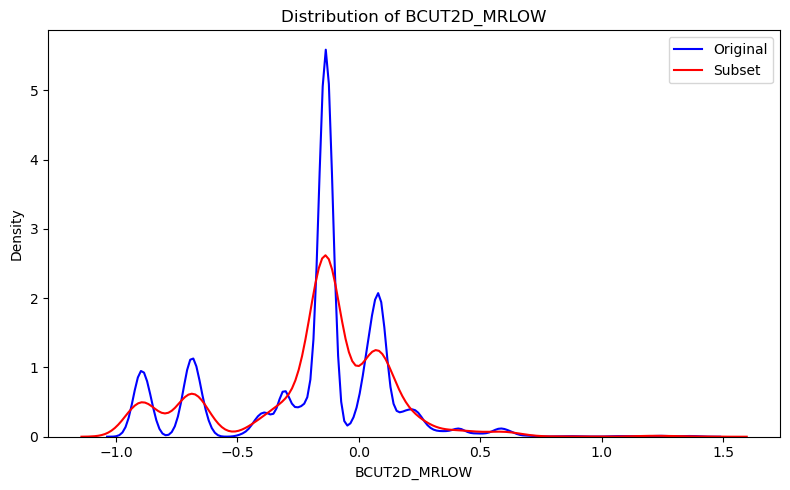

Skewness → Original: 0.75, Subset: 0.74
KS Test → Statistic: 0.0119, p-value: 0.5418
The distributions are similar


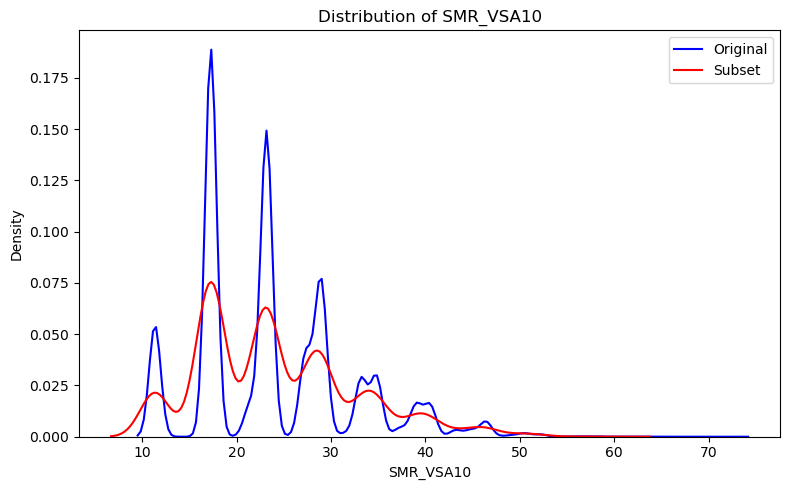

Skewness → Original: 0.39, Subset: 0.35
KS Test → Statistic: 0.0072, p-value: 0.9699
The distributions are similar


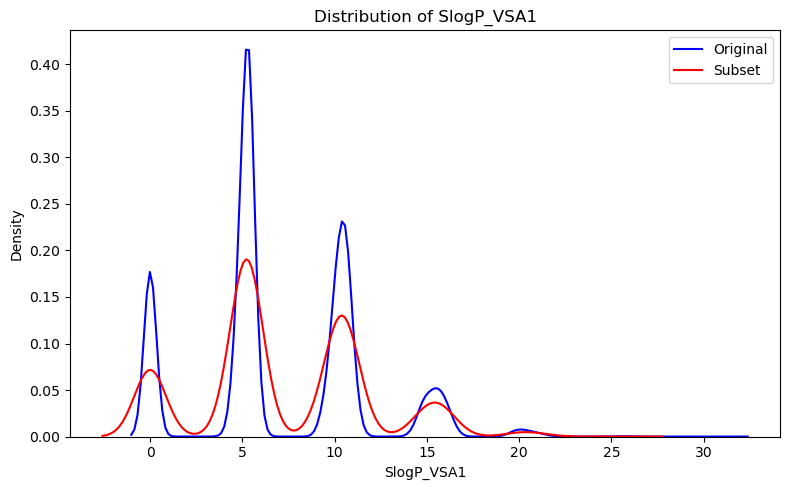

Skewness → Original: 0.27, Subset: 0.33
KS Test → Statistic: 0.0073, p-value: 0.9685
The distributions are similar


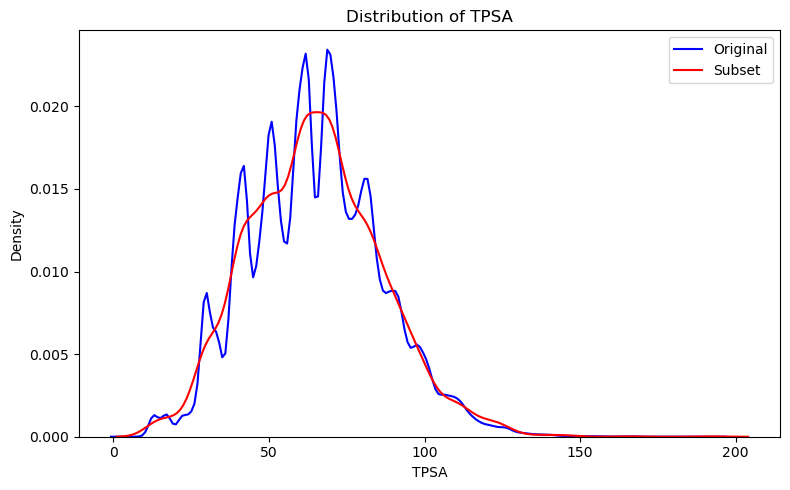

Skewness → Original: -0.10, Subset: -0.13
KS Test → Statistic: 0.0121, p-value: 0.5138
The distributions are similar


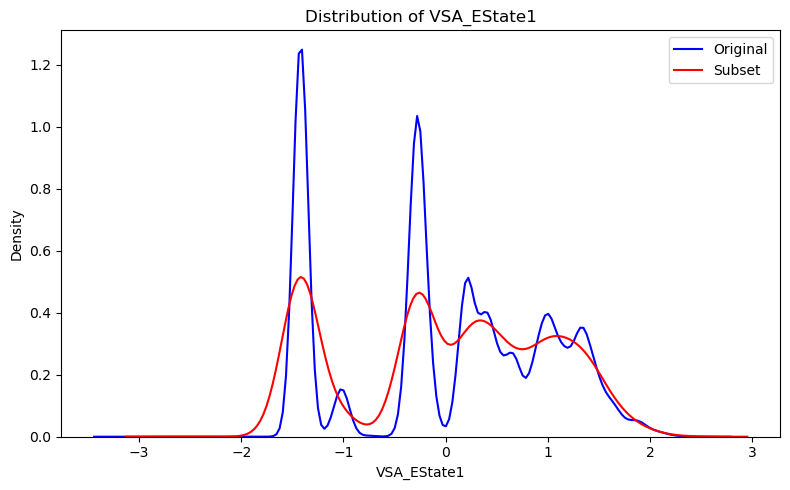

Skewness → Original: -0.01, Subset: 0.06
KS Test → Statistic: 0.0114, p-value: 0.5985
The distributions are similar


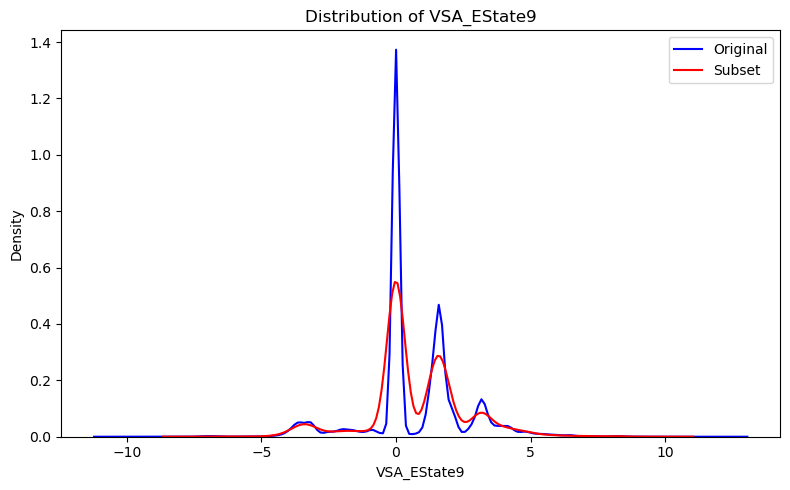

Skewness → Original: 0.55, Subset: 0.60
KS Test → Statistic: 0.0051, p-value: 0.9997
The distributions are similar


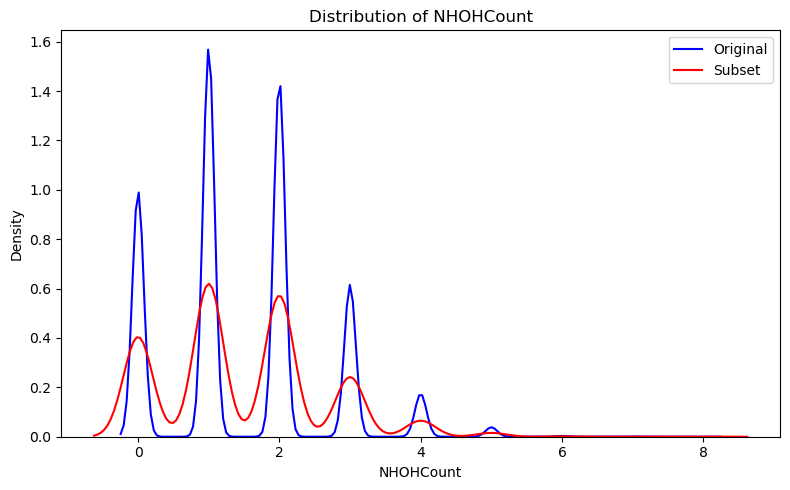

Skewness → Original: 1.52, Subset: 1.54
KS Test → Statistic: 0.0023, p-value: 1.0000
The distributions are similar


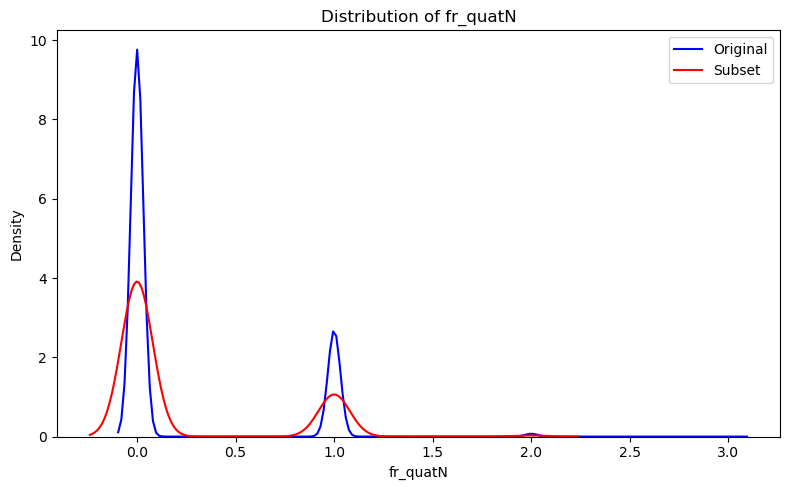

Skewness → Original: 0.31, Subset: -0.48
KS Test → Statistic: 0.0079, p-value: 0.9401
The distributions are similar


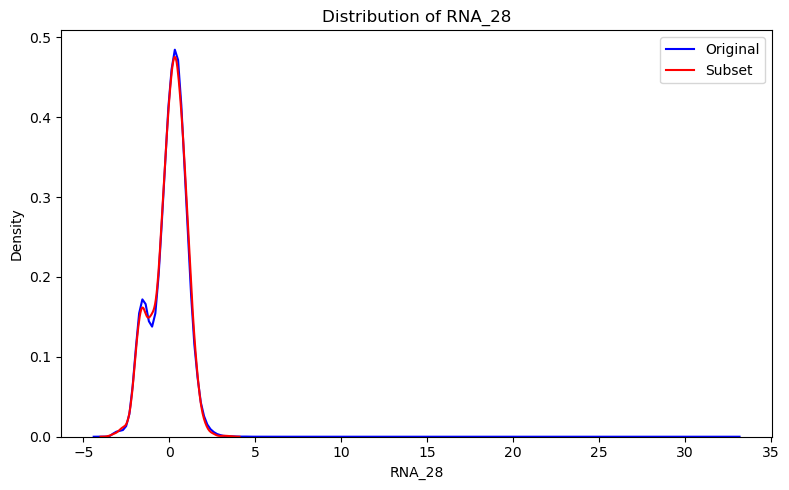

Skewness → Original: 6.11, Subset: 6.37
KS Test → Statistic: 0.0019, p-value: 1.0000
The distributions are similar


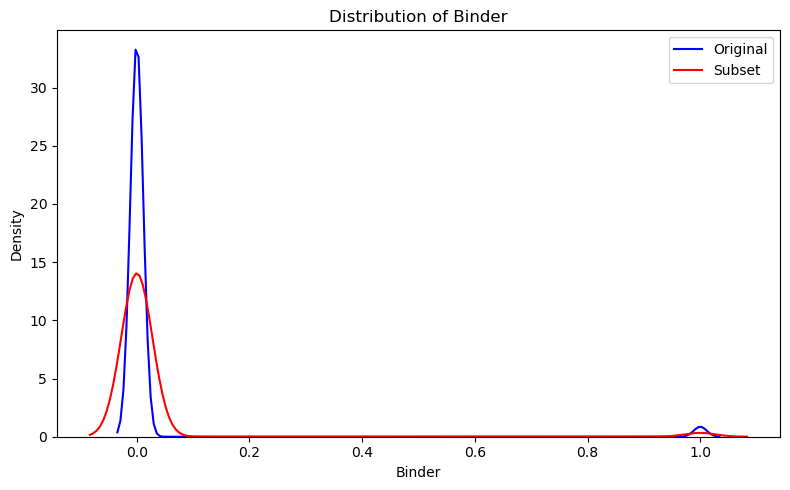

In [255]:
# Create a 4-% subset
subset_4, _ = create_stratified_subset(
    df=df_transformed,fraction=0.04,
    target_col='RNA_28',
    important_features=['fr_quatN', 'BCUT2D_MRLOW']
)
print(subset_1.shape)
print(subset_1.describe().T)
# Plot distributions of the target value and the important feature

# Filter numeric columns only
numeric_cols = subset_1.select_dtypes(include=['number']).columns
for col in subset_1:
    plot_feature_distribution(df_transformed, feature=col, subset_df=subset_1, subset_feature=col)

Train data shape: (14643, 12)
Train target shape: (14643,)
Test data shape: (3661, 12)
Test target shape: (3661,)
[LightGBM] [Info] Total Bins 2150
[LightGBM] [Info] Number of data points in the train set: 11714, number of used features: 12
[LightGBM] [Info] Start training from score 0.007213
[LightGBM] [Info] Total Bins 2153
[LightGBM] [Info] Number of data points in the train set: 11714, number of used features: 12
[LightGBM] [Info] Start training from score 0.002848
[LightGBM] [Info] Total Bins 2160
[LightGBM] [Info] Number of data points in the train set: 11714, number of used features: 12
[LightGBM] [Info] Start training from score 0.001912
[LightGBM] [Info] Total Bins 2153
[LightGBM] [Info] Number of data points in the train set: 11715, number of used features: 12
[LightGBM] [Info] Start training from score 0.004333
[LightGBM] [Info] Total Bins 2149
[LightGBM] [Info] Number of data points in the train set: 11715, number of used features: 12
[LightGBM] [Info] Start training from s

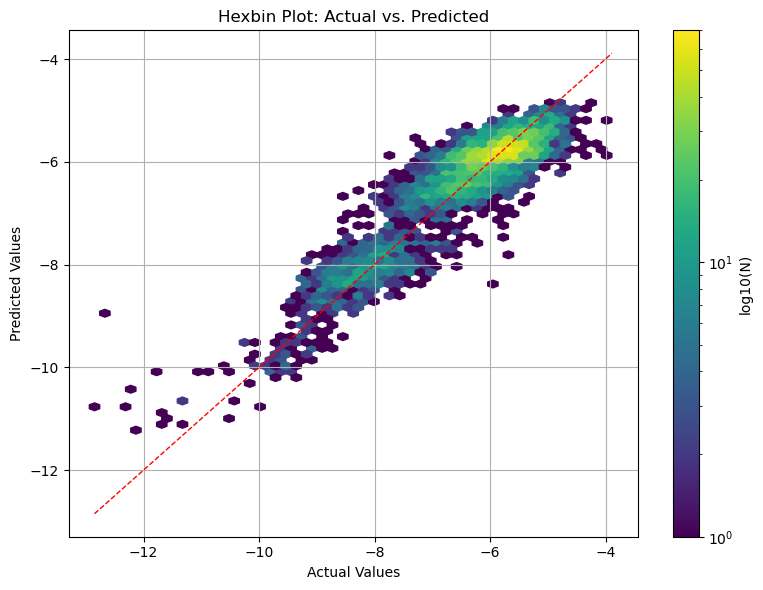

The RMSE score is: 0.4790
The R2 score is: 0.8341


(0.47900968843188096, 0.8340944274138244)

In [256]:
# Evaluate the model on the 4-% subset
# Data preprocessing 
x_train_4, x_test_4, y_train_4, y_test_4 = data_preprocessing(subset_4)
print(f'Train data shape: {x_train_4.shape}')
print(f'Train target shape: {y_train_4.shape}')
print(f'Test data shape: {x_test_4.shape}')
print(f'Test target shape: {y_test_4.shape}')
evaluate_model(
    model=stacked_averaged_models,
    x_train=x_train_4,x_test=x_test_4,y_train=y_train_4, y_test=y_test_4,
    target_col='RNA_28',
    transformer=transformers['RNA_28']  
)

[LightGBM] [Info] Total Bins 2150
[LightGBM] [Info] Number of data points in the train set: 11714, number of used features: 12
[LightGBM] [Info] Start training from score 0.007213
[LightGBM] [Info] Total Bins 2153
[LightGBM] [Info] Number of data points in the train set: 11714, number of used features: 12
[LightGBM] [Info] Start training from score 0.002848
[LightGBM] [Info] Total Bins 2160
[LightGBM] [Info] Number of data points in the train set: 11714, number of used features: 12
[LightGBM] [Info] Start training from score 0.001912
[LightGBM] [Info] Total Bins 2153
[LightGBM] [Info] Number of data points in the train set: 11715, number of used features: 12
[LightGBM] [Info] Start training from score 0.004333
[LightGBM] [Info] Total Bins 2149
[LightGBM] [Info] Number of data points in the train set: 11715, number of used features: 12
[LightGBM] [Info] Start training from score 0.000533


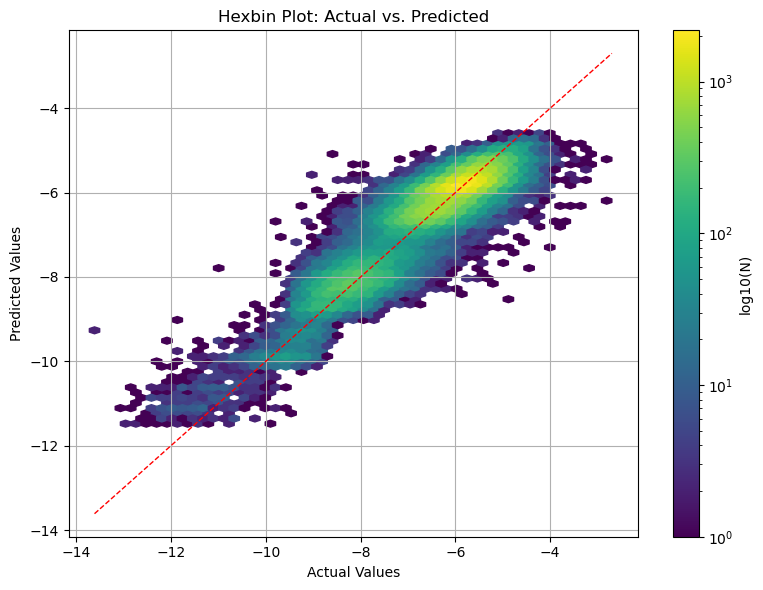

The RMSE score is: 0.4811
The R2 score is: 0.8300


(0.4810710541506265, 0.8300031567438363)

In [257]:
# Evaluate the stacked averaged model on the full dataset while trained on the 4-% subset
evaluate_model(
    model=stacked_averaged_models,
    x_train=x_train_4,x_test=x_test,y_train=y_train_4, y_test=y_test,
    target_col='RNA_28',
    transformer=transformers['RNA_28']  
)

(4576, 13)
                       count   mean    std    min    25%    50%    75%     max
MinPartialCharge    4576.000 -0.001  0.993 -3.330 -0.905  0.211  0.816   3.190
MaxAbsPartialCharge 4576.000  0.002  0.990 -3.424 -0.862 -0.000  0.890   3.350
BCUT2D_LOGPLOW      4576.000 -2.462  0.280 -3.182 -2.502 -2.401 -2.305  -1.734
BCUT2D_MRLOW        4576.000 -0.192  0.338 -0.955 -0.306 -0.137  0.042   1.409
SMR_VSA10           4576.000 24.061  8.373 11.337 17.244 23.213 28.907  59.127
SlogP_VSA1          4576.000  7.166  4.646  0.000  5.107  5.317 10.543  25.214
TPSA                4576.000 64.838 21.232 12.890 49.730 63.250 78.860 192.200
VSA_EState1         4576.000  0.004  0.994 -2.576 -1.019  0.171  0.874   2.400
VSA_EState9         4576.000  0.723  1.803 -7.653  0.000  0.000  1.645  10.046
NHOHCount           4576.000  1.480  1.121  0.000  1.000  1.000  2.000   8.000
fr_quatN            4576.000  0.224  0.430  0.000  0.000  0.000  0.000   2.000
RNA_28              4576.000 -0.002  0.96

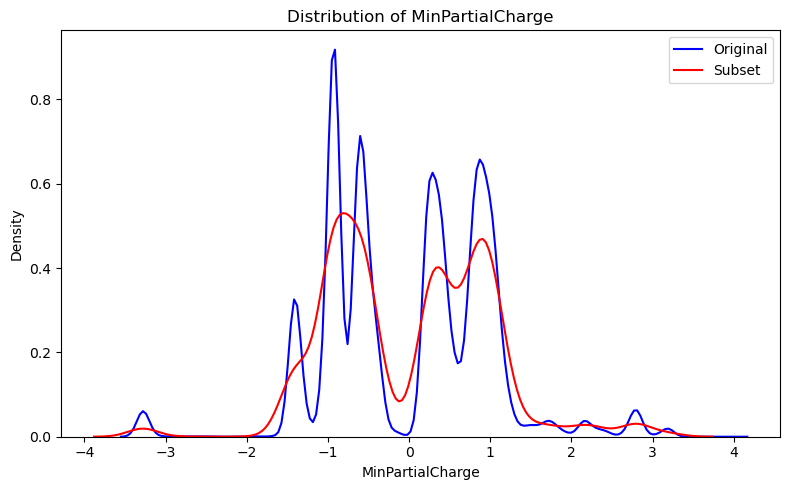

Skewness → Original: -0.05, Subset: -0.17
KS Test → Statistic: 0.0130, p-value: 0.4245
The distributions are similar


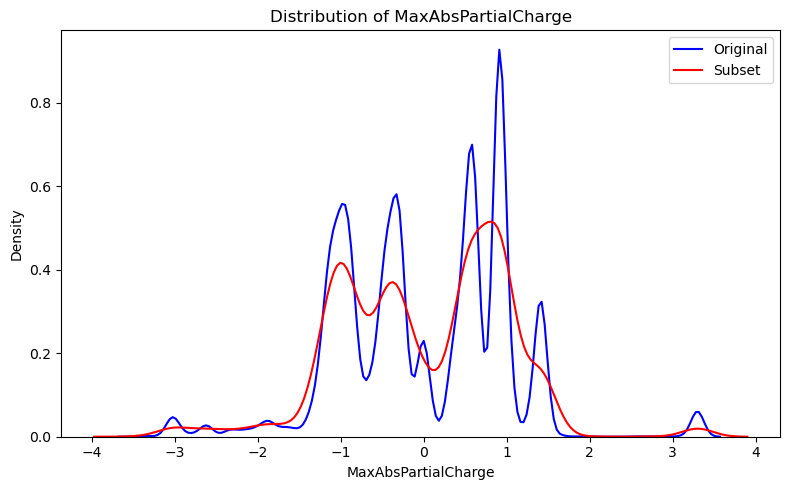

Skewness → Original: -0.89, Subset: -0.89
KS Test → Statistic: 0.0072, p-value: 0.9724
The distributions are similar


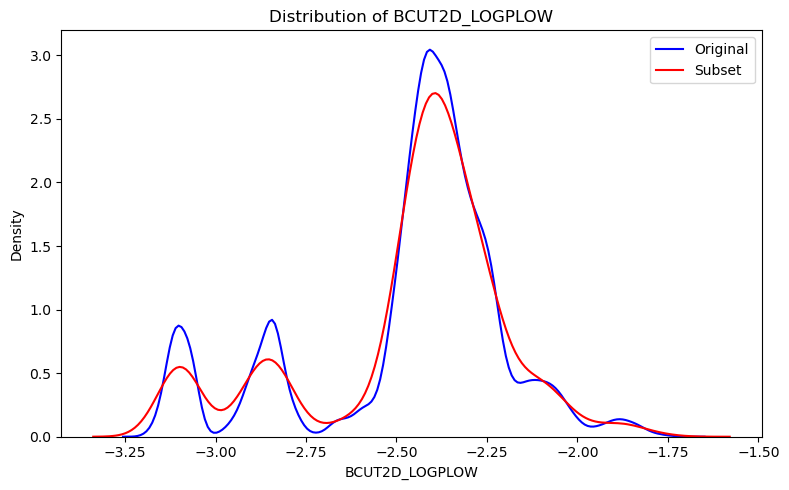

Skewness → Original: -0.34, Subset: -0.36
KS Test → Statistic: 0.0047, p-value: 1.0000
The distributions are similar


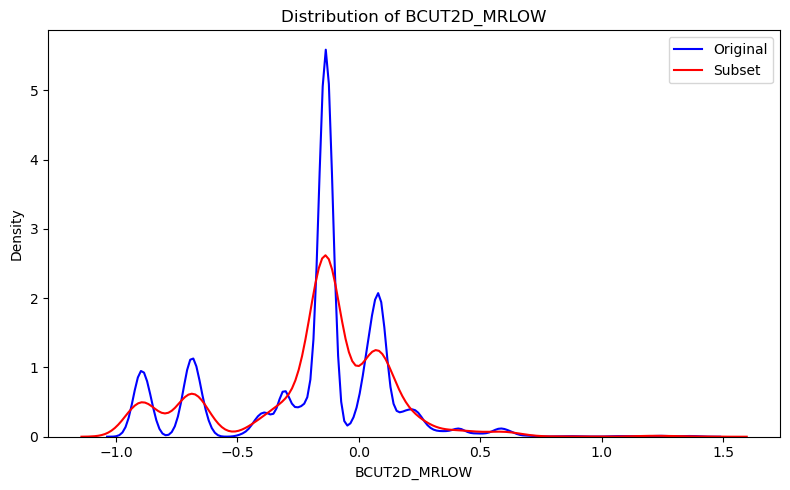

Skewness → Original: 0.75, Subset: 0.74
KS Test → Statistic: 0.0119, p-value: 0.5418
The distributions are similar


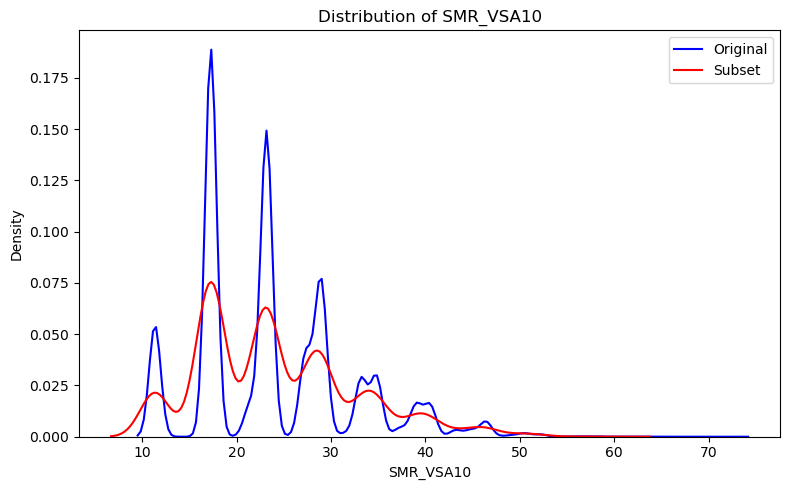

Skewness → Original: 0.39, Subset: 0.35
KS Test → Statistic: 0.0072, p-value: 0.9699
The distributions are similar


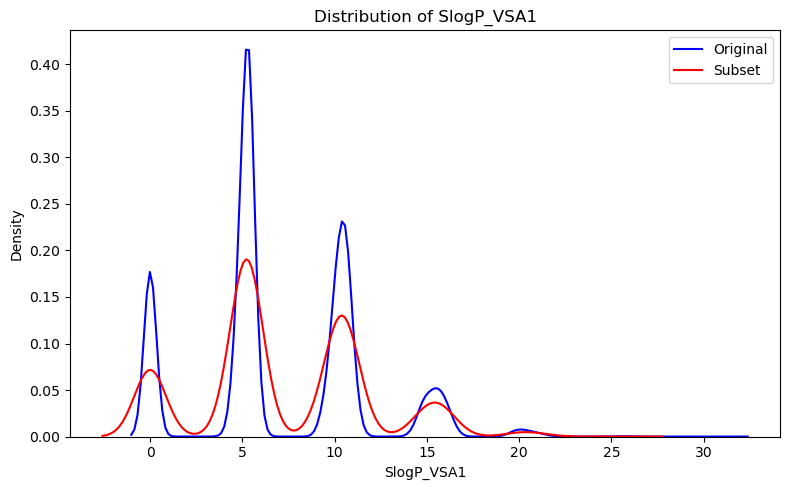

Skewness → Original: 0.27, Subset: 0.33
KS Test → Statistic: 0.0073, p-value: 0.9685
The distributions are similar


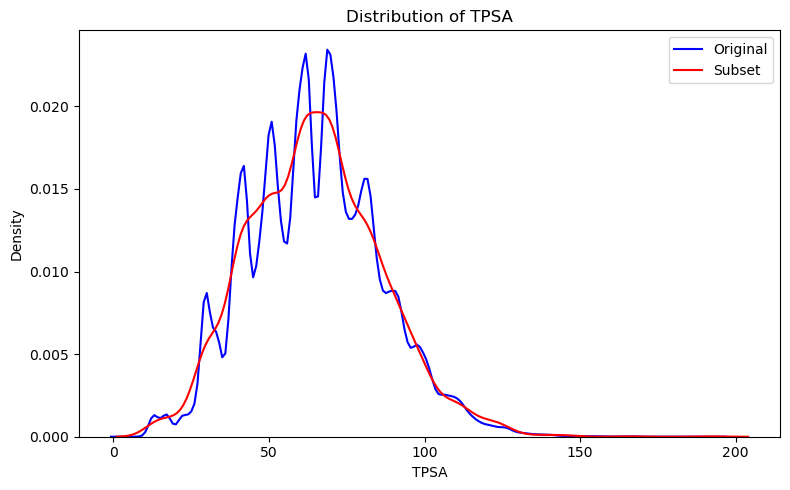

Skewness → Original: -0.10, Subset: -0.13
KS Test → Statistic: 0.0121, p-value: 0.5138
The distributions are similar


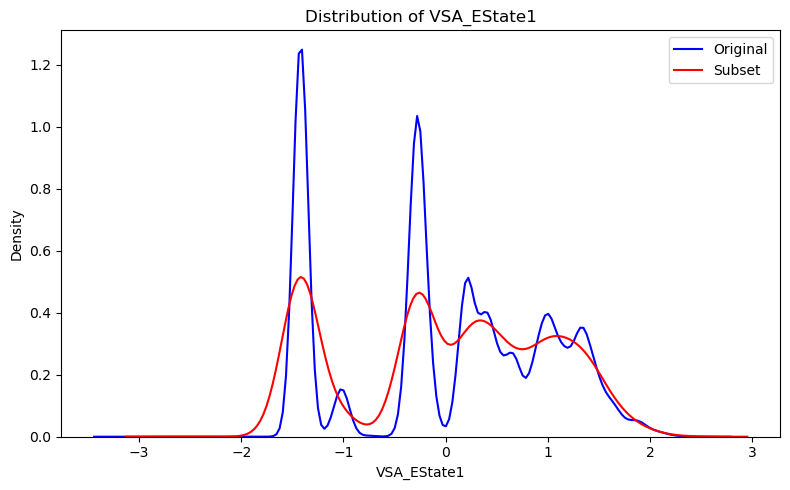

Skewness → Original: -0.01, Subset: 0.06
KS Test → Statistic: 0.0114, p-value: 0.5985
The distributions are similar


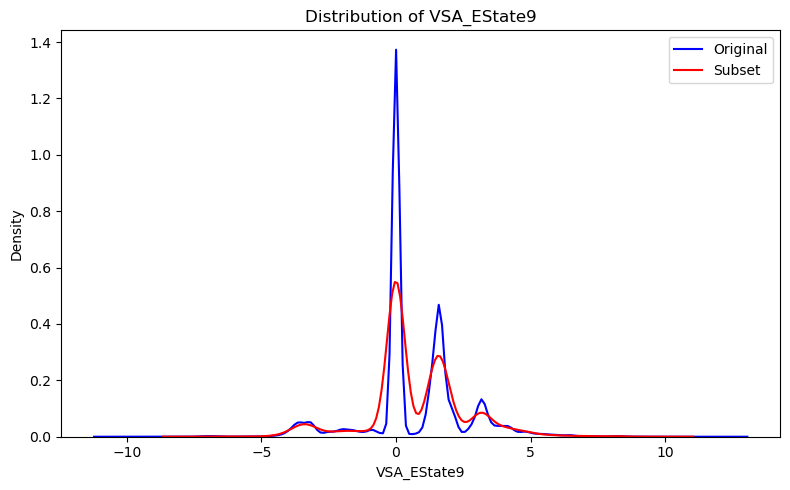

Skewness → Original: 0.55, Subset: 0.60
KS Test → Statistic: 0.0051, p-value: 0.9997
The distributions are similar


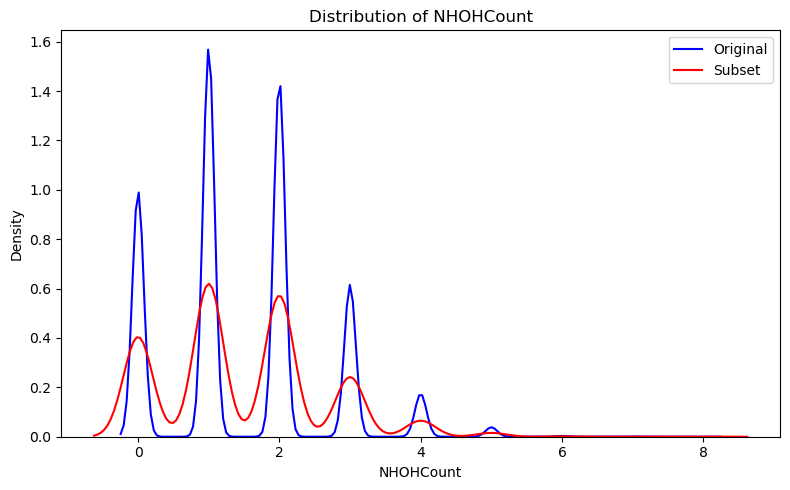

Skewness → Original: 1.52, Subset: 1.54
KS Test → Statistic: 0.0023, p-value: 1.0000
The distributions are similar


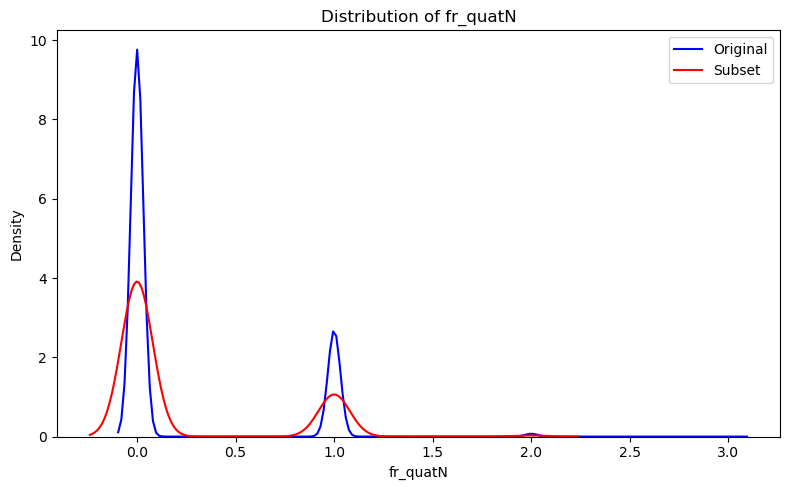

Skewness → Original: 0.31, Subset: -0.48
KS Test → Statistic: 0.0079, p-value: 0.9401
The distributions are similar


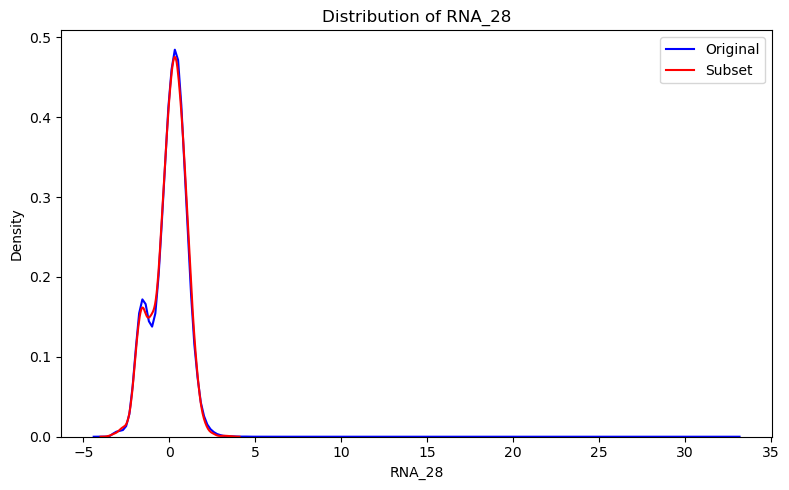

Skewness → Original: 6.11, Subset: 6.37
KS Test → Statistic: 0.0019, p-value: 1.0000
The distributions are similar


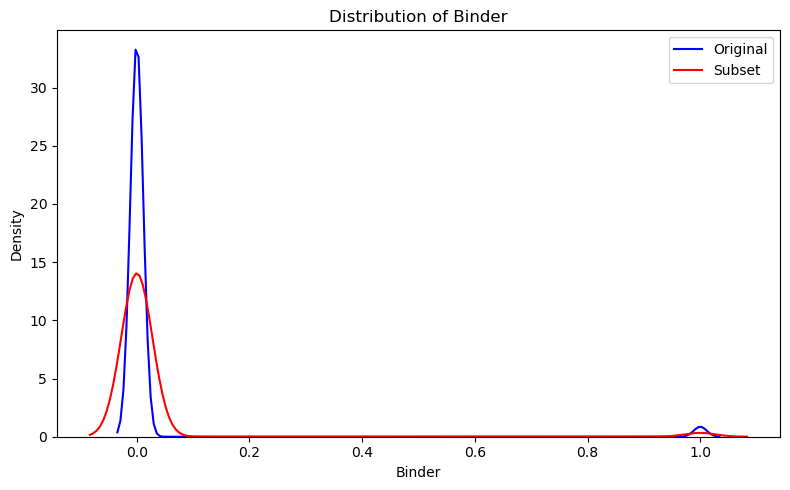

In [258]:
# Create a 5-% subset
subset_5, _ = create_stratified_subset(
    df=df_transformed,fraction=0.05,
    target_col='RNA_28',
    important_features=['fr_quatN', 'BCUT2D_MRLOW']
)
print(subset_1.shape)
print(subset_1.describe().T)
# Plot distributions of the target value and the important feature

# Filter numeric columns only
numeric_cols = subset_1.select_dtypes(include=['number']).columns
for col in subset_1:
    plot_feature_distribution(df_transformed, feature=col, subset_df=subset_1, subset_feature=col)

Train data shape: (18304, 12)
Train target shape: (18304,)
Test data shape: (4576, 12)
Test target shape: (4576,)
[LightGBM] [Info] Total Bins 2172
[LightGBM] [Info] Number of data points in the train set: 14643, number of used features: 12
[LightGBM] [Info] Start training from score 0.002678
[LightGBM] [Info] Total Bins 2164
[LightGBM] [Info] Number of data points in the train set: 14643, number of used features: 12
[LightGBM] [Info] Start training from score 0.001470
[LightGBM] [Info] Total Bins 2165
[LightGBM] [Info] Number of data points in the train set: 14643, number of used features: 12
[LightGBM] [Info] Start training from score -0.005181
[LightGBM] [Info] Total Bins 2165
[LightGBM] [Info] Number of data points in the train set: 14643, number of used features: 12
[LightGBM] [Info] Start training from score -0.000231
[LightGBM] [Info] Total Bins 2164
[LightGBM] [Info] Number of data points in the train set: 14644, number of used features: 12
[LightGBM] [Info] Start training from

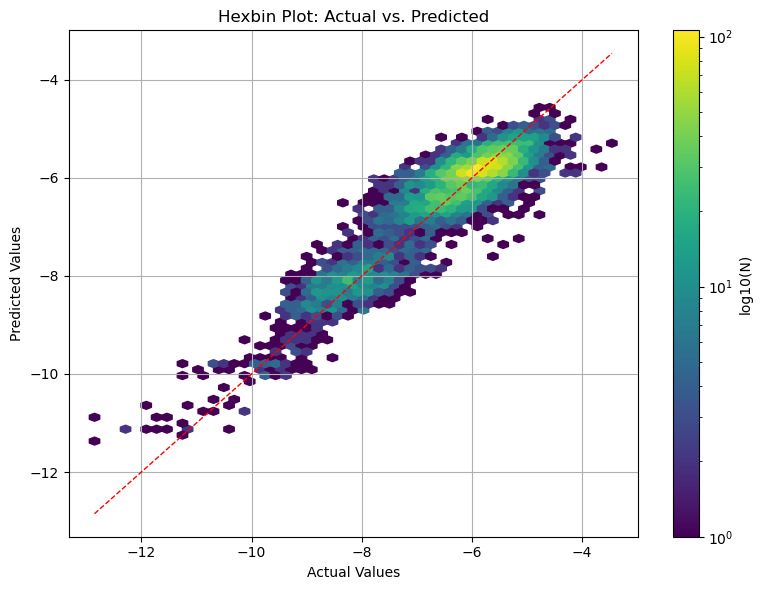

The RMSE score is: 0.4781
The R2 score is: 0.8357


(0.47809640449541296, 0.8357020636731757)

In [262]:
# Evaluate the model on the 5-% subset
# Data preprocessing 
x_train_5, x_test_5, y_train_5, y_test_5 = data_preprocessing(subset_5)
print(f'Train data shape: {x_train_5.shape}')
print(f'Train target shape: {y_train_5.shape}')
print(f'Test data shape: {x_test_5.shape}')
print(f'Test target shape: {y_test_5.shape}')
evaluate_model(
    model=stacked_averaged_models,
    x_train=x_train_5,x_test=x_test_5,y_train=y_train_5, y_test=y_test_5,
    target_col='RNA_28',
    transformer=transformers['RNA_28']  
)

[LightGBM] [Info] Total Bins 2172
[LightGBM] [Info] Number of data points in the train set: 14643, number of used features: 12
[LightGBM] [Info] Start training from score 0.002678
[LightGBM] [Info] Total Bins 2164
[LightGBM] [Info] Number of data points in the train set: 14643, number of used features: 12
[LightGBM] [Info] Start training from score 0.001470
[LightGBM] [Info] Total Bins 2165
[LightGBM] [Info] Number of data points in the train set: 14643, number of used features: 12
[LightGBM] [Info] Start training from score -0.005181
[LightGBM] [Info] Total Bins 2165
[LightGBM] [Info] Number of data points in the train set: 14643, number of used features: 12
[LightGBM] [Info] Start training from score -0.000231
[LightGBM] [Info] Total Bins 2164
[LightGBM] [Info] Number of data points in the train set: 14644, number of used features: 12
[LightGBM] [Info] Start training from score -0.004146


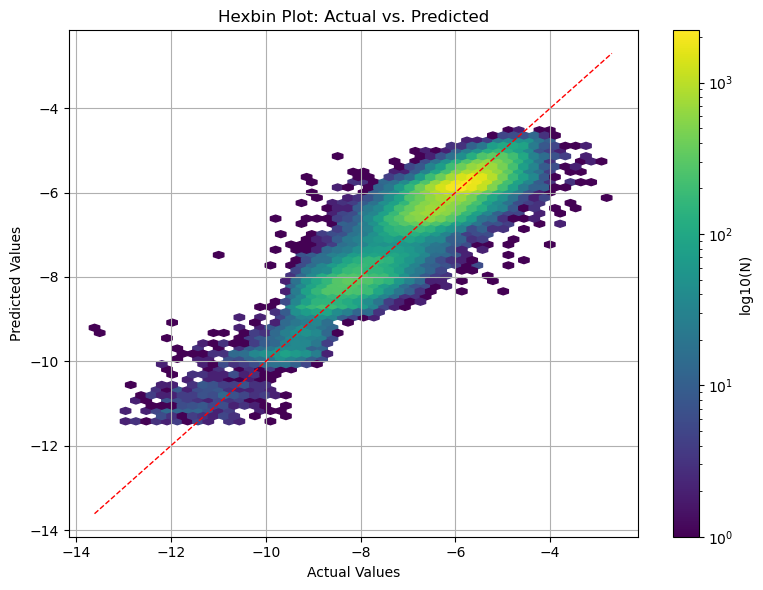

The RMSE score is: 0.4791
The R2 score is: 0.8314


(0.47905746524845866, 0.8314232686976394)

In [266]:
# Evaluate the stacked averaged model on the full dataset while trained on the 5-% subset
evaluate_model(
    model=stacked_averaged_models,
    x_train=x_train_5,x_test=x_test,y_train=y_train_5, y_test=y_test,
    target_col='RNA_28',
    transformer=transformers['RNA_28']  
)